In [1]:
import sys
import numpy as np

print("Python executable:")
print(sys.executable)
print("NumPy version:")
print(np.__version__)

Python executable:
C:\Users\ISherlock\AppData\Local\anaconda3\python.exe
NumPy version:
1.26.4


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path = r"C:\Users\ISherlock\OneDrive - Lambeth Council\Data\global_bleaching_environmental.csv"
#path = ".../data/global_bleaching_environmental.csv"

df = pd.read_csv(path, low_memory=False)

In [3]:
df.head()

,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,...,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,nd,Tropical Atlantic,Cuba and Cayman Islands,Cuba,...,5,0,0,0.74,7.25,0.18,2005-09-15,nd,nd,nd
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,nd,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,...,4,0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,nd
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,...,7,0,0,1.04,11.66,0.26,2006-01-15,nd,nd,nd
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,4,0,0,0.75,5.64,0.2,2006-04-15,nd,nd,nd
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,5,0,0,0.92,6.89,0.25,2006-04-15,nd,nd,nd


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41361 entries, 0 to 41360
Data columns (total 62 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Site_ID                                41361 non-null  int64  
 1   Sample_ID                              41361 non-null  int64  
 2   Data_Source                            41361 non-null  object 
 3   Latitude_Degrees                       41361 non-null  float64
 4   Longitude_Degrees                      41361 non-null  float64
 5   Ocean_Name                             41361 non-null  object 
 6   Reef_ID                                41361 non-null  object 
 7   Realm_Name                             41361 non-null  object 
 8   Ecoregion_Name                         41361 non-null  object 
 9   Country_Name                           41361 non-null  object 
 10  State_Island_Province_Name             41361 non-null  object 
 11  Ci

In [5]:
# SSTA_mean = sea surface temperature, depth of temp sensor unknown or variable, degrees C.

df['SSTA_Mean'].value_counts()

SSTA_Mean
0     41229
nd      132
Name: count, dtype: int64

In [6]:
# Bleaching level = assessed at what level. Not a severity score. Not useful for a target variable

df['Bleaching_Level'].value_counts()

Bleaching_Level
Population    22531
nd            18830
Name: count, dtype: int64

In [7]:
# Site exposure to fetch

df['Exposure']

0          Exposed
1          Exposed
2          Exposed
3          Exposed
4          Exposed
           ...    
41356    Sheltered
41357    Sheltered
41358    Sheltered
41359    Sheltered
41360    Sheltered
Name: Exposure, Length: 41361, dtype: object

In [8]:
# My target variable. An average of four transect segments (Reef Check) or average of a bleaching code

df['Percent_Bleaching'].value_counts()

Percent_Bleaching
0        16607
nd        6846
5.5       1184
75         914
0.25       882
         ...  
5.32         1
5.28         1
5.27         1
5.23         1
97.22        1
Name: count, Length: 2272, dtype: int64

In [9]:
df['Depth_m'].value_counts()

Depth_m
10       5021
5        3957
3        3884
6        2475
nd       1799
         ... 
2.87        1
6.89        1
1.15        1
13.72       1
25.6        1
Name: count, Length: 473, dtype: int64

In [10]:
# Percent cover is a method of determining relative abundance of a plant or sessile animal based on the amount of space they occupy

df['Percent_Cover'].value_counts()

Percent_Cover
nd       12455
0         6208
0.62      1248
1.25       878
1.88       612
         ...  
87.94        1
50.5         1
58.13        1
22.33        1
19.5         1
Name: count, Length: 360, dtype: int64

In [11]:
df['SSTA'].value_counts()

SSTA
0       386
0.51    310
0.36    294
0.42    283
0.46    279
       ... 
3.8       1
5.48      1
2.9       1
3.16      1
2.89      1
Name: count, Length: 667, dtype: int64

In [12]:
df['Bleaching_Comments'].value_counts()

Bleaching_Comments
nd                                                                     38692
Bleaching percentage averaged from code: Mild (1-10% Bleached)          1129
Bleaching percent averaged from code: Severe (>50% Bleached)             829
Bleaching percentage averaged from code: Moderate (11-50% Bleached)      655
Bleaching percent averaged from code: <= 10% Reef Area Bleached           24
Bleaching percent averaged from code: >50% Reef Area Bleached             20
Bleaching percent averaged from code: 10-25% Reef Area Bleached            6
Bleaching percent averaged from code: 25-50% Reef Area Bleached            6
Name: count, dtype: int64

In [13]:
# Lots of values missing from bleaching comments - better to use Bleaching_Percent to estimate severity

In [14]:
df['Realm_Name'].value_counts()

Realm_Name
Central Indo-Pacific           19101
Tropical Atlantic              14575
Western Indo-Pacific            4492
Eastern Indo-Pacific            1876
Temperate Northern Pacific       597
Temperate Australasia            577
Tropical Eastern Pacific         118
Temperate Northern Atlantic       17
Temperate Southern Africa          8
Name: count, dtype: int64

In [15]:
df.nunique()

Site_ID               12702
Sample_ID             27005
Data_Source               9
Latitude_Degrees      11066
Longitude_Degrees     11025
                      ...  
TSA_DHWMean             250
Date                   5212
Site_Comments           862
Sample_Comments        1305
Bleaching_Comments        8
Length: 62, dtype: int64

In [16]:
df.columns

Index(['Site_ID', 'Sample_ID', 'Data_Source', 'Latitude_Degrees',
       'Longitude_Degrees', 'Ocean_Name', 'Reef_ID', 'Realm_Name',
       'Ecoregion_Name', 'Country_Name', 'State_Island_Province_Name',
       'City_Town_Name', 'Site_Name', 'Distance_to_Shore', 'Exposure',
       'Turbidity', 'Cyclone_Frequency', 'Date_Day', 'Date_Month', 'Date_Year',
       'Depth_m', 'Substrate_Name', 'Percent_Cover', 'Bleaching_Level',
       'Percent_Bleaching', 'ClimSST', 'Temperature_Kelvin',
       'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum',
       'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA',
       'SSTA_Standard_Deviation', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum',
       'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation',
       'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW',
       'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA',
       'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean',
       'TSA_Freq

## Data cleaning & preparation
* Standardising missing values (nd → NaN)
* Fixing obvious errors
* Converting data types
* Removing duplicates
* Sanity checks

In [17]:
bleaching_df = df.copy()

In [18]:
bleaching_df = bleaching_df.drop(columns = ['Site_ID','Sample_ID', 'Data_Source','Reef_ID','Country_Name', 'State_Island_Province_Name',
       'City_Town_Name', 'Site_Name','Substrate_Name'])

In [19]:
# Convert to datetime

bleaching_df['Date'] = pd.to_datetime(bleaching_df['Date'])

In [20]:
# Define function to convert columns to numerical

def clean_numeric_column(df, column):
    df[column] = df[column].replace('nd', np.nan)
    df[column] = pd.to_numeric(df[column], errors='coerce')
    return df

In [21]:
cols = [
'Distance_to_Shore',
'Turbidity',
'Cyclone_Frequency',
'Date_Day',
'Date_Month',
'Date_Year',
'Depth_m',
'Percent_Cover',
'Percent_Bleaching',
'ClimSST',
'Temperature_Kelvin',
'Temperature_Mean',
'Temperature_Minimum',
'Temperature_Maximum',
'Temperature_Kelvin_Standard_Deviation',
'Windspeed',
'SSTA',
'SSTA_Standard_Deviation',
'SSTA_Mean',
'SSTA_Minimum',
'SSTA_Maximum',
'SSTA_Frequency',
'SSTA_Frequency_Standard_Deviation',
'SSTA_FrequencyMax',
'SSTA_FrequencyMean',
'SSTA_DHW',
'SSTA_DHW_Standard_Deviation',
'SSTA_DHWMax',
'SSTA_DHWMean',
'TSA',
'TSA_Standard_Deviation',
'TSA_Minimum',
'TSA_Maximum',
'TSA_Mean',                          
'TSA_Frequency',
'TSA_Frequency_Standard_Deviation',
'TSA_FrequencyMax',
'TSA_FrequencyMean',
'TSA_DHW',
'TSA_DHW_Standard_Deviation',
'TSA_DHWMax',
'TSA_DHWMean'
]

In [22]:
for col in cols:
    bleaching_df = clean_numeric_column(bleaching_df, col)

In [23]:
# Check that it worked

bleaching_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41361 entries, 0 to 41360
Data columns (total 53 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Latitude_Degrees                       41361 non-null  float64       
 1   Longitude_Degrees                      41361 non-null  float64       
 2   Ocean_Name                             41361 non-null  object        
 3   Realm_Name                             41361 non-null  object        
 4   Ecoregion_Name                         41361 non-null  object        
 5   Distance_to_Shore                      41359 non-null  float64       
 6   Exposure                               41361 non-null  object        
 7   Turbidity                              41355 non-null  float64       
 8   Cyclone_Frequency                      41361 non-null  float64       
 9   Date_Day                               41361 non-null  int64 

## Exploratory Data Analysis
* Basic summary statistics
* Assess data quality: identify missing values, errors
* Univariate analysis
* Bivariate analysis
* Identify outliers and anomolies
* Explore trends

##### Basic summary stats

In [24]:
bleaching_df[['Depth_m', 'ClimSST', 'Percent_Cover', 'Percent_Bleaching', 'Temperature_Kelvin','Windspeed','SSTA','TSA']].describe().round()

,Depth_m,ClimSST,Percent_Cover,Percent_Bleaching,Temperature_Kelvin,Windspeed,SSTA,TSA
count,39562.0,41248.0,28906.0,34515.0,41213.0,41232.0,41213.0,41213.0
mean,7.0,294.0,19.0,10.0,301.0,5.0,0.0,-1.0
std,4.0,15.0,21.0,20.0,2.0,2.0,1.0,2.0
min,0.0,262.0,0.0,0.0,287.0,0.0,-5.0,-12.0
25%,4.0,299.0,1.0,0.0,300.0,3.0,-0.0,-2.0
50%,6.0,301.0,12.0,0.0,302.0,5.0,0.0,-1.0
75%,10.0,302.0,33.0,6.0,303.0,6.0,1.0,0.0
max,90.0,307.0,100.0,100.0,310.0,15.0,6.0,6.0


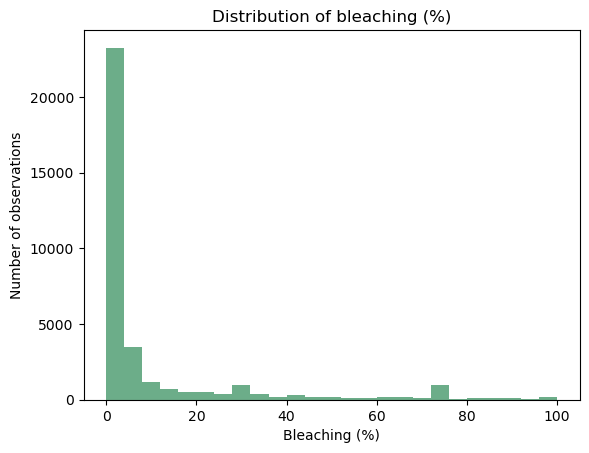

In [25]:
plt.hist(bleaching_df['Percent_Bleaching'], bins =25, color='seagreen', alpha=0.7)
plt.xlabel('Bleaching (%)')
plt.ylabel('Number of observations')
plt.title('Distribution of bleaching (%)')
plt.show()

In [26]:
counts, bins = np.histogram(
    bleaching_df['Percent_Bleaching'],
    bins=25,
    range=(0, 100)
)

hist_df = pd.DataFrame({
    'Bin_start': bins[:-1],
    'Bin_end': bins[1:],
    'Count': counts
})

hist_df['Percent_of_total'] = (
    hist_df['Count'] / hist_df['Count'].sum() * 100
)

hist_df

,Bin_start,Bin_end,Count,Percent_of_total
0,0.0,4.0,23255,67.376503
1,4.0,8.0,3454,10.007243
2,8.0,12.0,1186,3.436187
3,12.0,16.0,729,2.112125
4,16.0,20.0,493,1.428364
5,20.0,24.0,516,1.495002
6,24.0,28.0,389,1.127046
7,28.0,32.0,955,2.766913
8,32.0,36.0,352,1.019846
9,36.0,40.0,199,0.576561


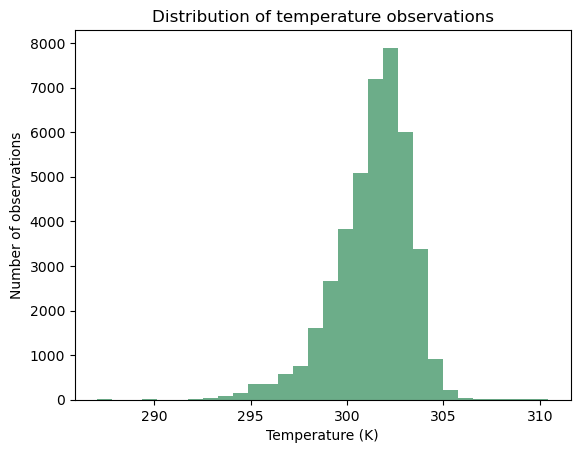

In [27]:
plt.hist(bleaching_df['Temperature_Kelvin'], bins=30, color='seagreen', alpha=0.7)
plt.xlabel('Temperature (K)')
plt.ylabel('Number of observations')
plt.title('Distribution of temperature observations')

plt.show()

### Check data quality & missing values

In [28]:
bleaching_df.isna().mean() * 100

Latitude_Degrees                          0.000000
Longitude_Degrees                         0.000000
Ocean_Name                                0.000000
Realm_Name                                0.000000
Ecoregion_Name                            0.000000
Distance_to_Shore                         0.004835
Exposure                                  0.000000
Turbidity                                 0.014506
Cyclone_Frequency                         0.000000
Date_Day                                  0.000000
Date_Month                                0.000000
Date_Year                                 0.000000
Depth_m                                   4.349508
Percent_Cover                            30.112908
Bleaching_Level                           0.000000
Percent_Bleaching                        16.551824
ClimSST                                   0.273204
Temperature_Kelvin                        0.357825
Temperature_Mean                          0.319141
Temperature_Minimum            

##### Why this works
* isna() → True where values are NaN
* True is treated as 1, False as 0
* mean() → proportion of NaNs
* *100 → percentage

### Investigate columns with non-nulls

##### Depth
* Water depth, in meters
* Predictor variable

In [29]:
bleaching_df['Depth_m'].isna().mean() * 100

4.349507990619182

##### Why 4% missing is not a problem:
* <5% missing = very low
* Bias risk from imputation is minimal
* Keep >95% of observations
* Depth is ecologically important for bleaching → worth preserving

→ So this is a technical choice, not a red flag.

In [30]:
bleaching_df['Depth_m'].value_counts()

Depth_m
10.00    5021
5.00     3957
3.00     3884
6.00     2475
4.00     1669
         ... 
20.75       1
11.09       1
4.57        1
16.64       1
25.60       1
Name: count, Length: 465, dtype: int64

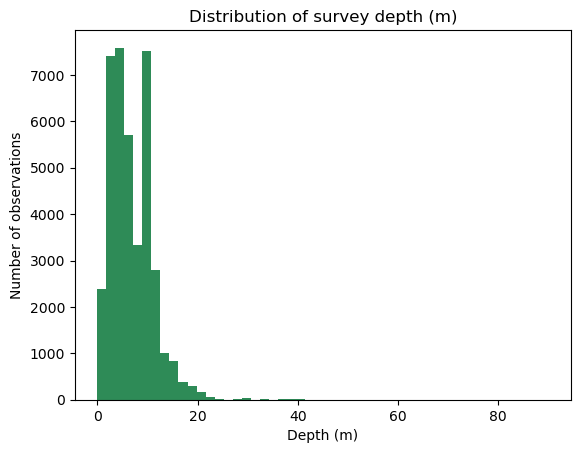

In [31]:
plt.hist(bleaching_df['Depth_m'], bins=50, color='seagreen')
plt.xlabel("Depth (m)")
plt.ylabel("Number of observations")
plt.title("Distribution of survey depth (m)")

plt.show()

##### Percent Cover
* Percent cover is a method of determining relative abundance of a plant or sessile animal based on the amount of space they occupy within a plot of substrate. In this method, rather than counting the number of individuals, each species is assigned a percent cover based on a visual estimate of how much of the sample plot they occupy.
* Not measured in all surveys
* Relies on visual estimates
* Predictor variable

In [32]:
bleaching_df['Percent_Cover'].isna().mean() * 100

30.11290829525398

In [33]:
bleaching_df['Percent_Cover'].value_counts()

Percent_Cover
0.00     6208
0.62     1248
1.25      878
1.88      612
2.50      532
         ... 
87.94       1
50.50       1
58.13       1
22.33       1
19.50       1
Name: count, Length: 359, dtype: int64

##### Why 30% missing is risky
For a variable like percent cover:
* It is contextual and observer‑dependent
* Ecological meaning depends on when and how it is measured
* Imputing 30% of values would create invented ecological structure

This is especially problematic because:
* Percent cover strongly correlates with habitat, depth, and survey type
* Imputation would implicitly assume those relationships are stable and known, but they are not

##### Importance in ecology ≠ importance in an ML model
Percent cover is ecologically meaningful:
* It reflects benthic structure
* It relates to light, competition, and community composition
* It can influence susceptibility to bleaching

However, in an ML context a variable is “important” only if it:
* Adds predictive information not already captured, and
* Does so reliably across the dataset

→ These are separate questions.

In [34]:
pc_obs = bleaching_df.dropna(subset=['Percent_Cover'])

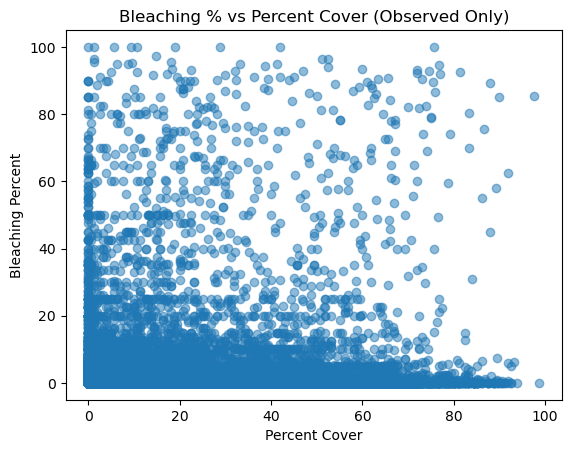

In [35]:
plt.scatter(
    pc_obs['Percent_Cover'],
    pc_obs['Percent_Bleaching'],
    alpha=0.5
)
plt.xlabel('Percent Cover')
plt.ylabel('Bleaching Percent')
plt.title('Bleaching % vs Percent Cover (Observed Only)')
plt.show()


##### What is the relationship between bleaching percent and percent cover? 
* Most reefs experience low bleaching most of the time (cluster of values between 0-20% bleaching and between 0-100 percent cover)
* Low cover can still experience bleaching (cluster up y axis)
* Bleaching is not prevented by low cover
* High bleaching and high cover is less frequent

This indicates that:
- No clear linear relationship
- Model will be able to learn bleaching patterns without it

→ Exclude percent cover from ML feature selection

##### Percent bleaching
* Coral bleaching percentage
* Target variable

Because target variable → analyse missingness and then most likely drop

In [36]:
bleaching_df['Percent_Bleaching'].value_counts()

Percent_Bleaching
0.00     16629
5.50      1184
75.00      914
0.25       882
1.00       705
         ...  
6.13         1
6.11         1
6.09         1
5.98         1
97.22        1
Name: count, Length: 2240, dtype: int64

In [37]:
bleaching_df['Percent_Bleaching'].isna().sum()

6846

In [38]:
bleaching_df["Percent_Bleaching"].dtype

dtype('float64')

In [39]:
bleaching_df["target_missing"] = bleaching_df["Percent_Bleaching"].isna().astype(int)

In [40]:
bleaching_df['target_missing'].value_counts()

target_missing
0    34515
1     6846
Name: count, dtype: int64

In [41]:
# Check key predictors by missingness
bleaching_df.groupby("target_missing")[["Depth_m", "ClimSST"]].describe()

Depth_m                                                 \
                  count      mean       std  min  25%  50%   75%   max   
target_missing                                                           
0               32834.0  7.052727  4.233982  0.0  4.0  6.0  10.0  50.3   
1                6728.0  6.284728  3.729366  0.4  3.0  5.0  10.0  90.0   

                ClimSST                                                  \
                  count        mean        std     min     25%      50%   
target_missing                                                            
0               34420.0  294.173526  14.793875  262.15  298.57  300.795   
1                6828.0  294.180595  14.829244  262.15  298.41  300.850   

                                
                   75%     max  
target_missing                  
0               301.99  307.22  
1               302.08  306.60

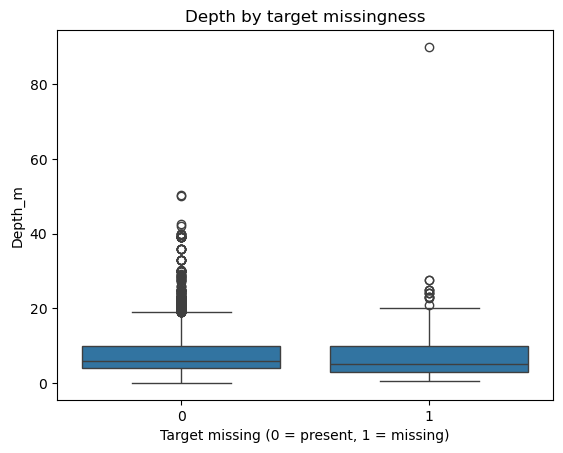

In [42]:
sns.boxplot(
    data=bleaching_df,
    x="target_missing",
    y="Depth_m"
)
plt.xlabel("Target missing (0 = present, 1 = missing)")
plt.title("Depth by target missingness")
plt.show()

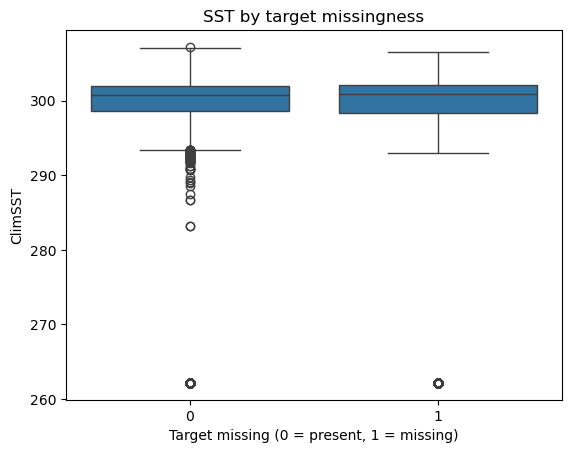

In [43]:
sns.boxplot(
    data=bleaching_df,
    x="target_missing",
    y="ClimSST"
)
plt.xlabel("Target missing (0 = present, 1 = missing)")
plt.title("SST by target missingness")
plt.show()


In [44]:
missing_by_year = (
    bleaching_df
    .groupby("Date_Year")["target_missing"]
    .mean()
)

missing_by_year

Date_Year
1980    0.000000
1983    0.400000
1984    1.000000
1985    1.000000
1986    0.500000
1987    0.647059
1988    0.000000
1989    1.000000
1990    0.250000
1991    0.222222
1992    0.000000
1993    0.181818
1994    0.173913
1995    0.600000
1996    0.035714
1997    0.971939
1998    0.375000
1999    0.393669
2000    0.479394
2001    0.572595
2002    0.529075
2003    0.179803
2004    0.116736
2005    0.046183
2006    0.041867
2007    0.117015
2008    0.061584
2009    0.129118
2010    0.127739
2011    0.036222
2012    0.059060
2013    0.076970
2014    0.077276
2015    0.061409
2016    0.023720
2017    0.014935
2018    0.001606
2019    0.006689
2020    0.000000
Name: target_missing, dtype: float64

In [45]:
bleaching_df.groupby("Date_Year").size().loc[[1984, 1985, 1989]]

Date_Year
1984    1
1985    1
1989    1
dtype: int64

##### Early years show data availability issues (not ecological signal)
The very high missingness in the 1980s–early 1990s almost certainly reflects:
* Sparse early monitoring
* Inconsistent recording of bleaching metrics
* Historical data integration gaps

This is normal and expected in global environmental datasets.

##### Missingness declines sharply over time
From ~2004 onward:
* Missingness is consistently below ~15%
* After ~2016 it is near zero

This suggests:
* Improved survey methods
* More standardised bleaching reporting
* Much stronger data quality in recent years

This strongly supports dropping missing targets without serious bias for modern analyses.

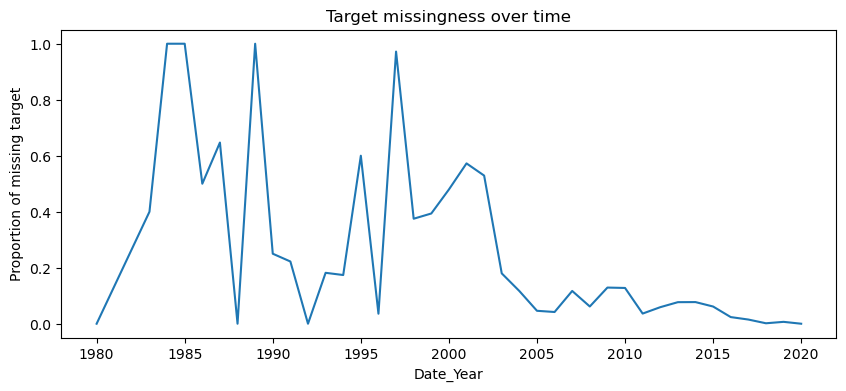

In [46]:
missing_by_year.plot(figsize=(10, 4))
plt.ylabel("Proportion of missing target")
plt.title("Target missingness over time")
plt.show()

In [47]:
count_by_year = bleaching_df.groupby("Date_Year").size()

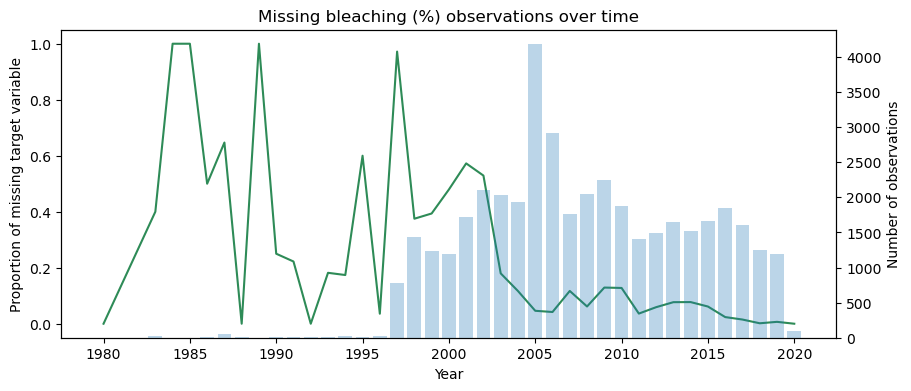

In [48]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    missing_by_year.index,
    missing_by_year.values,
    color = 'seagreen'
)

ax.set_ylabel("Proportion of missing target variable")
ax.set_xlabel('Year')
ax.set_title("Missing bleaching (%) observations over time")

ax_data = ax.twinx()

ax_data.bar(
    count_by_year.index,
    count_by_year.values,
    alpha=0.3
)

ax_data.set_ylabel("Number of observations")

plt.show()

In [49]:
missing_by_region = (
    bleaching_df
    .groupby("Realm_Name")["target_missing"]
    .mean()
    .sort_values(ascending=False)
)

missing_by_region

Realm_Name
Temperate Southern Africa      1.000000
Central Indo-Pacific           0.222920
Western Indo-Pacific           0.220614
Tropical Eastern Pacific       0.203390
Temperate Northern Atlantic    0.176471
Temperate Northern Pacific     0.149079
Tropical Atlantic              0.087136
Eastern Indo-Pacific           0.086354
Temperate Australasia          0.071057
Name: target_missing, dtype: float64

In [50]:
bleaching_df[bleaching_df["Realm_Name"] == "Temperate Southern Africa"].shape[0]

8

In [51]:
missing_by_region = (
    bleaching_df
    .groupby("Ocean_Name")["target_missing"]
    .mean()
    .sort_values(ascending=False)
)

missing_by_region

Ocean_Name
Indian          0.238048
Red Sea         0.236785
Pacific         0.203233
Arabian Gulf    0.157534
Atlantic        0.087240
Name: target_missing, dtype: float64

##### What to do with rows where percent bleaching is missing?
* Missing values are seen across the df and concentrated in earlier years
* Years with 100% missing have a single or very few rows
* Missingness is random across regions
* Model cannot learn from rows where the target is missing
* Imputing would introduce artificial bias

→ Drop rows with missing values for ML

### Bivariate analysis

In [52]:
df['Ocean_Name'].value_counts()

Ocean_Name
Pacific         21896
Atlantic        14592
Indian           3054
Red Sea          1381
Arabian Gulf      438
Name: count, dtype: int64

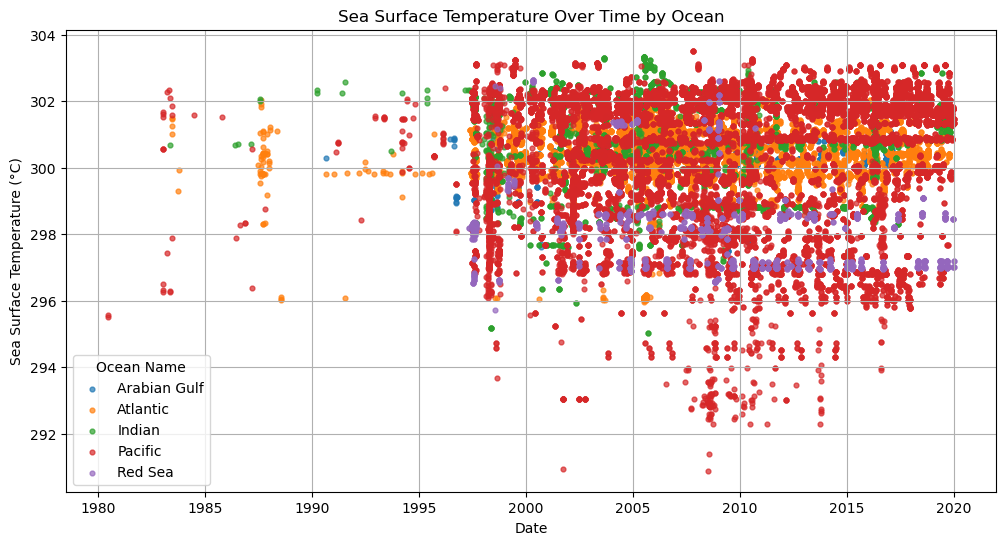

In [53]:
plt.figure(figsize=(12, 6))

for ocean, group in bleaching_df.groupby("Ocean_Name"):
    plt.scatter(
        group["Date"],
        group["Temperature_Mean"],
        label=ocean,
        s=12,
        alpha=0.7
    )

plt.xlabel("Date")
plt.ylabel("Sea Surface Temperature (°C)")
plt.title("Sea Surface Temperature Over Time by Ocean")
plt.legend(title="Ocean Name")
plt.grid(True)
plt.show()

<Axes: xlabel='Date_Year'>

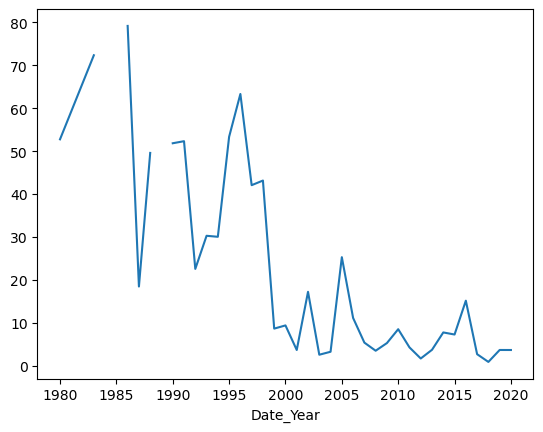

In [54]:
bleaching_df.groupby("Date_Year")["Percent_Bleaching"].mean().plot()

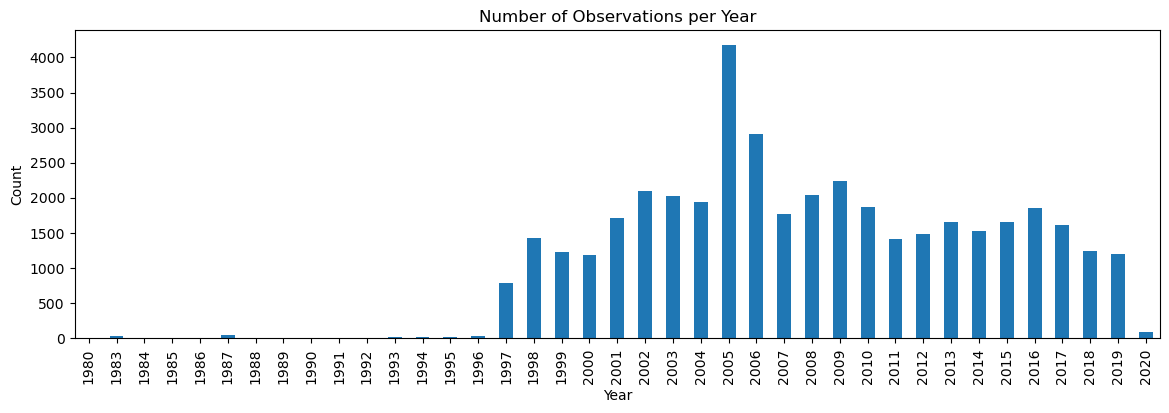

In [55]:
year_counts = df["Date_Year"].value_counts().sort_index()
year_counts.plot(kind="bar", figsize=(14,4))
plt.title("Number of Observations per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

In [56]:
bleaching_df.columns

Index(['Latitude_Degrees', 'Longitude_Degrees', 'Ocean_Name', 'Realm_Name',
       'Ecoregion_Name', 'Distance_to_Shore', 'Exposure', 'Turbidity',
       'Cyclone_Frequency', 'Date_Day', 'Date_Month', 'Date_Year', 'Depth_m',
       'Percent_Cover', 'Bleaching_Level', 'Percent_Bleaching', 'ClimSST',
       'Temperature_Kelvin', 'Temperature_Mean', 'Temperature_Minimum',
       'Temperature_Maximum', 'Temperature_Kelvin_Standard_Deviation',
       'Windspeed', 'SSTA', 'SSTA_Standard_Deviation', 'SSTA_Mean',
       'SSTA_Minimum', 'SSTA_Maximum', 'SSTA_Frequency',
       'SSTA_Frequency_Standard_Deviation', 'SSTA_FrequencyMax',
       'SSTA_FrequencyMean', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation',
       'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'TSA_Standard_Deviation',
       'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean', 'TSA_Frequency',
       'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax',
       'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation',
       'TSA_DHWMax', 'TSA_

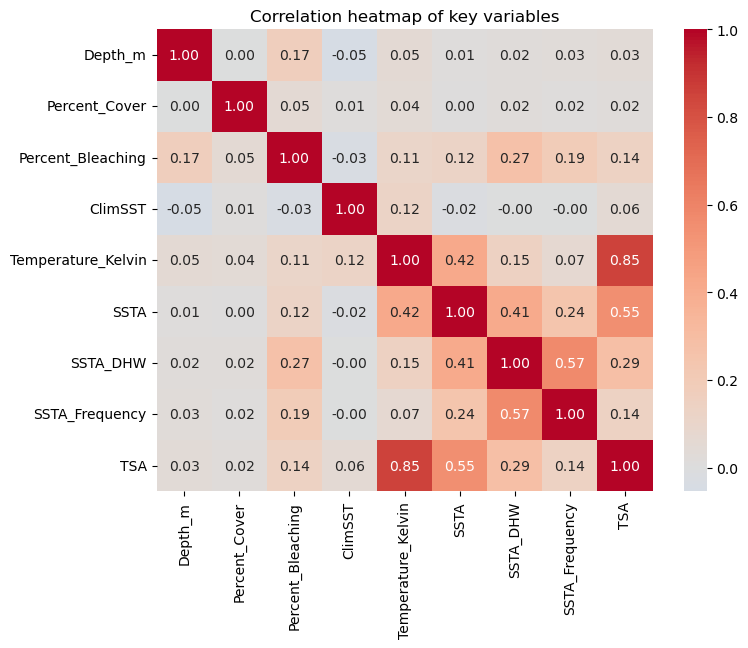

In [57]:
corr_df = bleaching_df[[
    'Depth_m',
    'Percent_Cover',
    'Percent_Bleaching', 
    'ClimSST',
    'Temperature_Kelvin',
    'SSTA',
    'SSTA_DHW',
    'SSTA_Frequency',
    'TSA'
]]

corr = corr_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Correlation heatmap of key variables")
plt.show()

In [58]:
corr

,Depth_m,Percent_Cover,Percent_Bleaching,ClimSST,Temperature_Kelvin,SSTA,SSTA_DHW,SSTA_Frequency,TSA
Depth_m,1.000000,0.001574,0.165545,-0.054293,0.054174,0.011666,0.019053,0.031138,0.033238
Percent_Cover,0.001574,1.000000,0.051962,0.011617,0.044228,0.004202,0.016329,0.015065,0.016035
Percent_Bleaching,0.165545,0.051962,1.000000,-0.034744,0.107627,0.119348,0.272392,0.188832,0.142379
ClimSST,-0.054293,0.011617,-0.034744,1.000000,0.123378,-0.015401,-0.001539,-0.003480,0.056395
Temperature_Kelvin,0.054174,0.044228,0.107627,0.123378,1.000000,0.417710,0.151575,0.069191,0.852912
SSTA,0.011666,0.004202,0.119348,-0.015401,0.417710,1.000000,0.409283,0.244160,0.547529
SSTA_DHW,0.019053,0.016329,0.272392,-0.001539,0.151575,0.409283,1.000000,0.572576,0.289545
SSTA_Frequency,0.031138,0.015065,0.188832,-0.003480,0.069191,0.244160,0.572576,1.000000,0.135791
TSA,0.033238,0.016035,0.142379,0.056395,0.852912,0.547529,0.289545,0.135791,1.000000


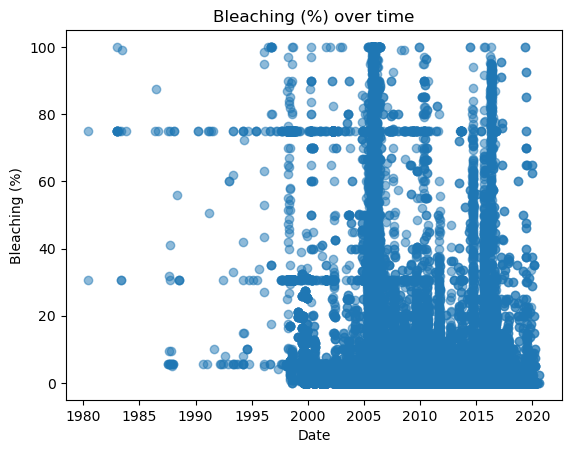

In [59]:
plt.scatter(bleaching_df['Date'], bleaching_df['Percent_Bleaching'], alpha = 0.5)

plt.xlabel("Date")
plt.ylabel("Bleaching (%)")
plt.title("Bleaching (%) over time")

plt.show()

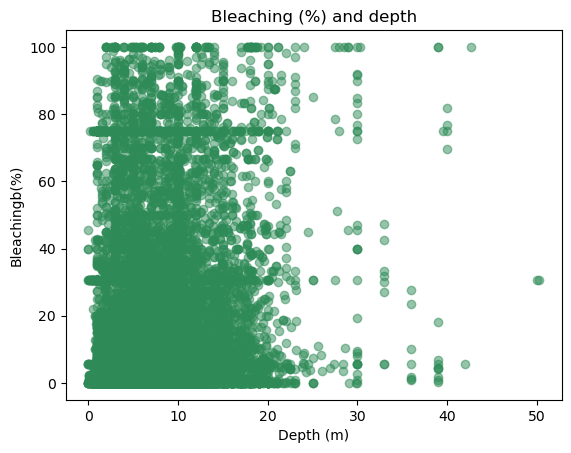

In [60]:
plt.scatter(bleaching_df['Depth_m'], bleaching_df['Percent_Bleaching'],alpha=0.5, color = 'seagreen')

plt.xlabel("Depth (m)")
plt.ylabel("Bleachingb(%)")
plt.title("Bleaching (%) and depth")

plt.show()

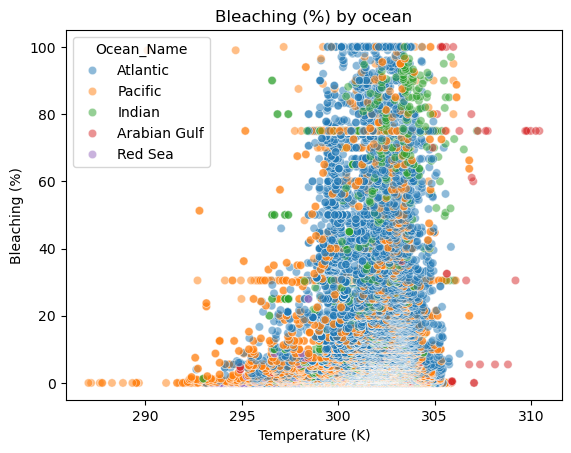

In [61]:
sns.scatterplot(
    data=bleaching_df,
    x="Temperature_Kelvin",
    y="Percent_Bleaching",
    hue="Ocean_Name",
    alpha=0.5
)

plt.xlabel("Temperature (K)")
plt.ylabel("Bleaching (%)")
plt.title("Bleaching (%) by ocean")
plt.show()


<Figure size 640x480 with 0 Axes>

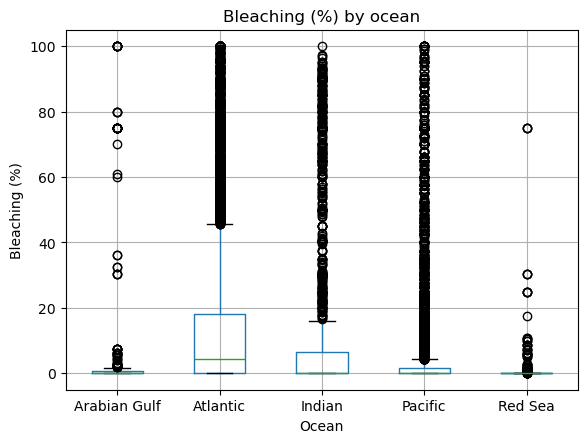

In [62]:
plt.figure()
bleaching_df.boxplot(column="Percent_Bleaching", by="Ocean_Name")

plt.title("Bleaching (%) by ocean")
plt.suptitle("")  # removes automatic pandas title
plt.xlabel("Ocean")
plt.ylabel("Bleaching (%)")

plt.show()

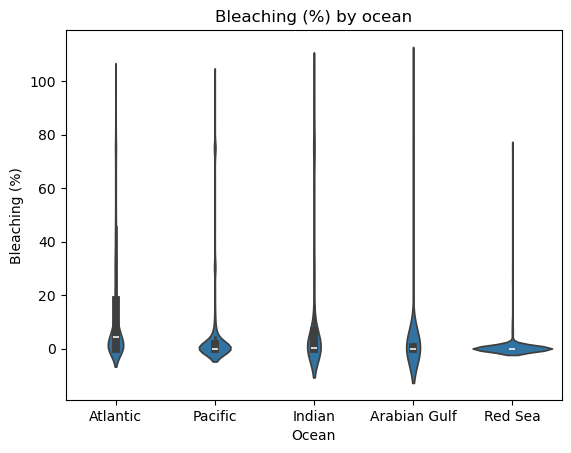

In [63]:
plt.figure()
sns.violinplot(
    x="Ocean_Name",
    y="Percent_Bleaching",
    data=bleaching_df
)

plt.title("Bleaching (%) by ocean")
plt.xlabel("Ocean")
plt.ylabel("Bleaching (%)")

plt.show()

<Figure size 640x480 with 0 Axes>

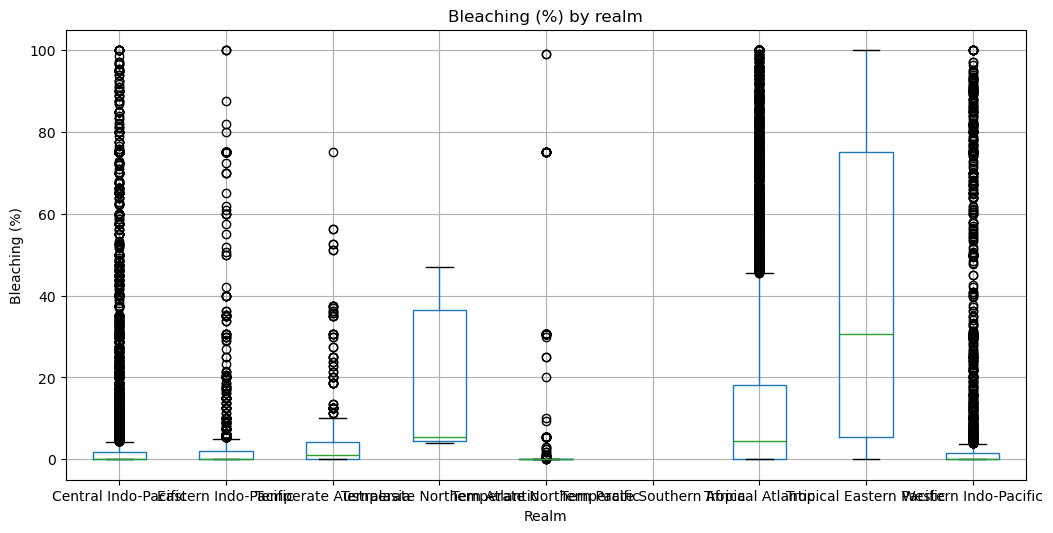

In [64]:
plt.figure()
bleaching_df.boxplot(column="Percent_Bleaching", by="Realm_Name", figsize = (12,6))

plt.title("Bleaching (%) by realm")
plt.suptitle("") 
plt.xlabel("Realm")
plt.ylabel("Bleaching (%)")

plt.show()

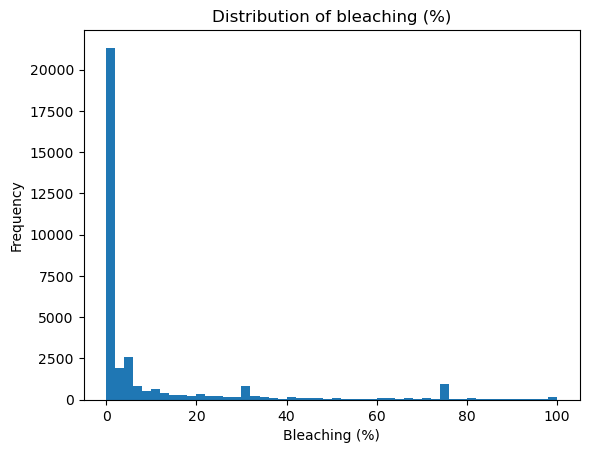

In [65]:
plt.hist(bleaching_df["Percent_Bleaching"], bins=50)
plt.xlabel("Bleaching (%)")
plt.ylabel("Frequency")
plt.title("Distribution of bleaching (%)")
plt.show()

In [66]:
bleaching_df["Percent_Bleaching"].skew()

2.5904297192656984

* skew ≈ 0 → roughly symmetric
* skew > 0.5 → moderately right-skewed
* skew > 1 → strongly right-skewed
* skew < -0.5 → left-skewed

## Regional variation in bleaching

In [67]:
# Basic summary by ocean
ocean_summary = (
    bleaching_df
    .groupby("Ocean_Name")
    .agg(
        min_bleaching=("Percent_Bleaching", "min"),
        max_bleaching=("Percent_Bleaching", "max"),
        mean_bleaching=("Percent_Bleaching", "mean"),
        median_bleaching=("Percent_Bleaching", "median"),
        observations=("Percent_Bleaching", "count")
    )
    .reset_index()
)

ocean_summary.round(2)

,Ocean_Name,min_bleaching,max_bleaching,mean_bleaching,median_bleaching,observations
0,Arabian Gulf,0.0,100.0,6.68,0.00,369
1,Atlantic,0.0,100.0,14.40,4.46,13319
2,Indian,0.0,100.0,12.91,0.25,2327
3,Pacific,0.0,100.0,6.13,0.00,17446
4,Red Sea,0.0,75.0,0.66,0.00,1054


This table shows substantial variation in coral bleaching severity and frequency across ocean basins. The Atlantic Ocean exhibits the highest mean (14%) and median (5%) bleaching, indicating relatively frequent and persistent bleaching events. The Indian Ocean also shows a high mean bleaching level (13%) but a low median (0.3%), suggesting that bleaching there is less frequent overall but can be severe when it occurs.

In contrast, the Pacific Ocean and Arabian Gulf have lower mean bleaching (6% and 7%, respectively) and median values of zero, indicating that most observations record little or no bleaching, with impacts driven by episodic events rather than chronic bleaching. The Red Sea displays the lowest bleaching severity across all summary statistics, with a very low mean (0.7%) and median of zero, suggesting comparatively high resistance or lower exposure to bleaching within this dataset.

Overall, the results indicate different bleaching regimes across oceans, with the Atlantic and Indian Oceans characterised by higher average bleaching, and the Pacific and Arabian Gulf showing more intermittent but variable bleaching, while the Red Sea experiences consistently low bleaching levels.

Note small sample size for the Arabian Gulf.

In [68]:
# Basic summary by realm
realm_summary = (
    bleaching_df
    .groupby("Realm_Name")
    .agg(
        ocean_name=('Ocean_Name', 'first'),
        min_bleaching=("Percent_Bleaching", "min"),
        max_bleaching=("Percent_Bleaching", "max"),
        mean_bleaching=("Percent_Bleaching", "mean"),
        median_bleaching=("Percent_Bleaching", "median"),
        observations=("Percent_Bleaching", "count")
    )
    .reset_index()
)

realm_summary.round(2)

,Realm_Name,ocean_name,min_bleaching,max_bleaching,mean_bleaching,median_bleaching,observations
0,Central Indo-Pacific,Pacific,0.0,100.0,6.17,0.00,14843
1,Eastern Indo-Pacific,Pacific,0.0,100.0,5.48,0.00,1714
2,Temperate Australasia,Pacific,0.0,75.0,4.88,1.00,536
3,Temperate Northern Atlantic,Atlantic,4.0,47.0,18.10,5.50,14
4,Temperate Northern Pacific,Pacific,0.0,99.0,5.75,0.00,508
5,Temperate Southern Africa,Indian,NaN,NaN,NaN,NaN,0
6,Tropical Atlantic,Atlantic,0.0,100.0,14.40,4.44,13305
7,Tropical Eastern Pacific,Pacific,0.0,100.0,37.49,30.50,94
8,Western Indo-Pacific,Indian,0.0,100.0,8.60,0.00,3501


In [69]:
ocean_quantiles = (
    bleaching_df
    .groupby("Ocean_Name")["Percent_Bleaching"]
    .quantile([0.5, 0.75, 0.9])
    .unstack()
    .reset_index()
)

ocean_quantiles.columns = [
    "Ocean",
    "Median_bleaching",
    "Q75_bleaching",
    "Q90_bleaching"
]

ocean_quantiles.round(2)

,Ocean,Median_bleaching,Q75_bleaching,Q90_bleaching
0,Arabian Gulf,0.00,0.75,7.50
1,Atlantic,4.46,18.20,47.50
2,Indian,0.25,6.50,67.04
3,Pacific,0.00,1.75,18.62
4,Red Sea,0.00,0.00,0.25


* Indian Ocean shows the highest extreme bleaching (Q90 ≈ 67%)
* Atlantic also shows very high extremes (Q90 ≈ 48%)
* Pacific has moderate extremes (Q90 ≈ 19%)
* Arabian Gulf has lower extremes than expected (Q90 ≈ 7.5%)
* Red Sea shows exceptionally low bleaching across all metrics

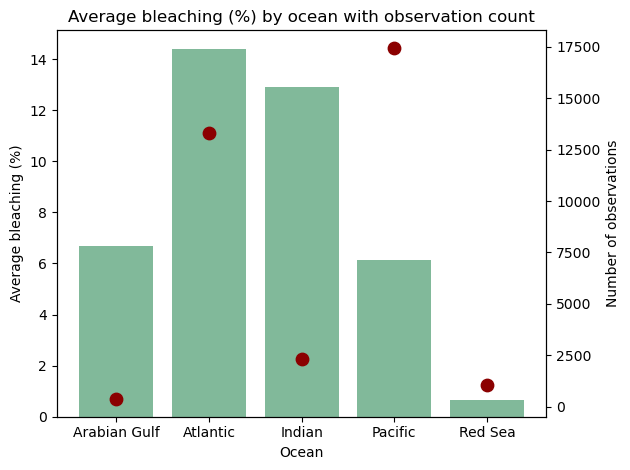

In [70]:
fig, ax1 = plt.subplots()

ax1.bar(
    ocean_summary["Ocean_Name"],
    ocean_summary["mean_bleaching"],
    color="seagreen",
    alpha=0.6
)
ax1.set_xlabel("Ocean")
ax1.set_ylabel("Average bleaching (%)")
ax1.tick_params(axis="y")

ax2 = ax1.twinx()
ax2.scatter(
    ocean_summary["Ocean_Name"],
    ocean_summary["observations"],
    color="darkred",
    s=80
)
ax2.set_ylabel("Number of observations")
ax2.tick_params(axis="y")

plt.title("Average bleaching (%) by ocean with observation count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

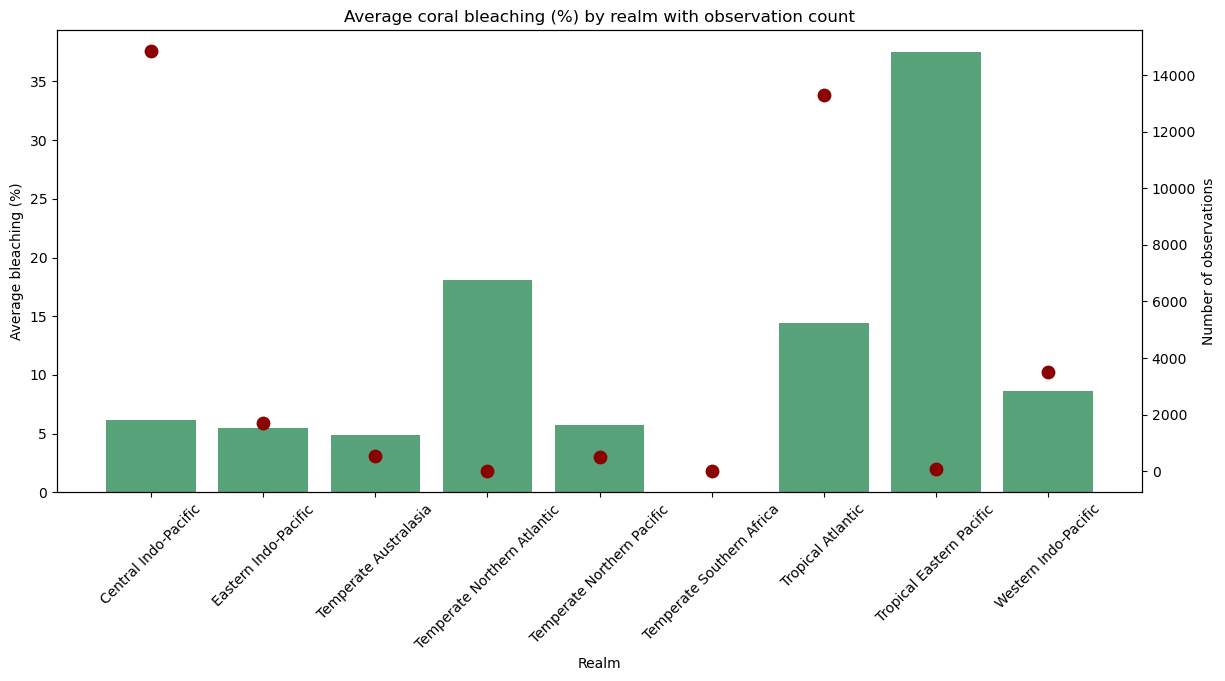

In [71]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(
    realm_summary["Realm_Name"],
    realm_summary["mean_bleaching"],
    color="seagreen",
    alpha=0.8
)
ax1.set_xlabel("Realm")
ax1.set_ylabel("Average bleaching (%)")
ax1.tick_params(axis="y")

ax2 = ax1.twinx()
ax2.scatter(
    realm_summary["Realm_Name"],
    realm_summary["observations"],
    color="darkred",
    s=80
)
ax2.set_ylabel("Number of observations")
ax2.tick_params(axis="y")

plt.title("Average coral bleaching (%) by realm with observation count")
ax1.tick_params(axis="x", rotation=45)

plt.show()

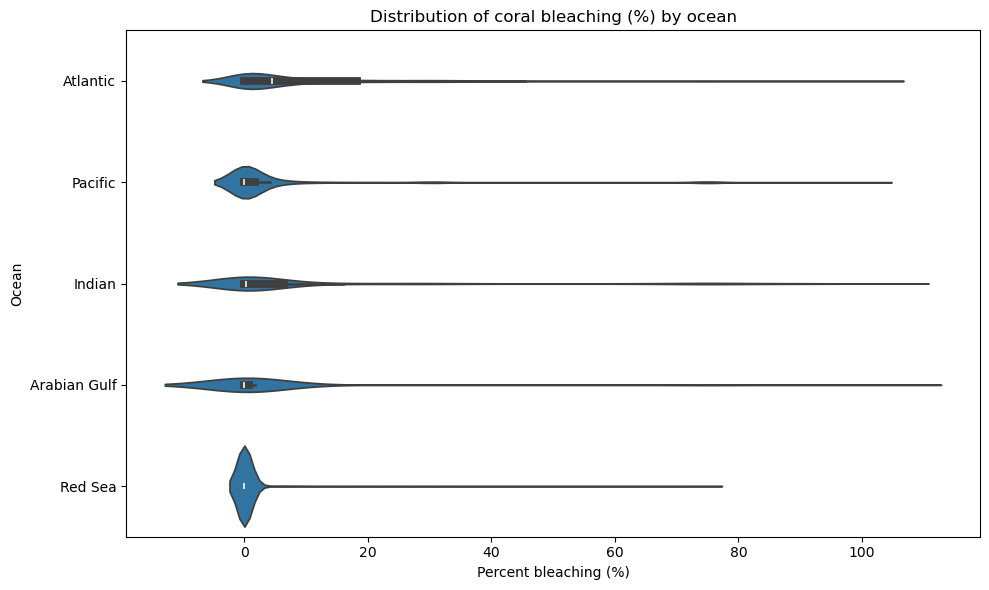

In [72]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=bleaching_df,
    x="Percent_Bleaching",
    y="Ocean_Name",
    orient="h"
)

plt.xlabel("Percent bleaching (%)")
plt.ylabel("Ocean")
plt.title("Distribution of coral bleaching (%) by ocean")

plt.tight_layout()
plt.show()

In [73]:
from scipy.stats import kruskal

bleaching_by_ocean = [
    bleaching_df.loc[bleaching_df["Ocean_Name"] == ocean, "Percent_Bleaching"].dropna()
    for ocean in bleaching_df["Ocean_Name"].unique()
]

stat, p_value = kruskal(*bleaching_by_ocean)

print(f"Kruskal-Wallis statistic: {stat:.2f}")
print(f"P-value: {p_value:.4f}")

Kruskal-Wallis statistic: 4886.31
P-value: 0.0000


In [74]:
#!pip install scikit-posthocs

In [75]:
import scikit_posthocs as sp

# Pairwise statistical comparisons of bleaching severity between oceans

dunn_results = sp.posthoc_dunn(
    bleaching_df,
    val_col="Percent_Bleaching",
    group_col="Ocean_Name",
    p_adjust="bonferroni"
)

dunn_results

,Arabian Gulf,Atlantic,Indian,Pacific,Red Sea
Arabian Gulf,1.000000e+00,9.297788e-29,2.424412e-05,1.000000e+00,8.124439e-11
Atlantic,9.297788e-29,1.000000e+00,6.399610e-49,0.000000e+00,2.655088e-218
Indian,2.424412e-05,6.399610e-49,1.000000e+00,2.027172e-33,1.979191e-73
Pacific,1.000000e+00,0.000000e+00,2.027172e-33,1.000000e+00,8.327848e-37
Red Sea,8.124439e-11,2.655088e-218,1.979191e-73,8.327848e-37,1.000000e+00


In [76]:
# True = two oceans are significantly different (p< 0.05)
# False = no statistically significant difference

significant_pairs = dunn_results < 0.05
significant_pairs

,Arabian Gulf,Atlantic,Indian,Pacific,Red Sea
Arabian Gulf,False,True,True,False,True
Atlantic,True,False,True,True,True
Indian,True,True,False,True,True
Pacific,False,True,True,False,True
Red Sea,True,True,True,True,False


## Are some oceans more vulnerable than others?

#### Atlantic Ocean: High overall vulnerability (chronic + severe extremes)
* Highest mean bleaching (14.40%)
* Highest median bleaching (4.46%) → bleaching is relatively frequent
* Very high 90th percentile bleaching (47.5%)
* Statistically distinct from all other oceans
* Large observation count → results are robust

The Atlantic Ocean experiences frequent bleaching combined with severe extreme events, indicating high and persistent vulnerability. This suggests both chronic thermal stress and susceptibility to major bleaching episodes.

Assessment: Most consistently vulnerable ocean overall

#### Indian Ocean: High vulnerability driven by extreme events
* High mean bleaching (12.91%)
* Low median (0.25%) → bleaching is less frequent overall
* Highest 90th percentile bleaching (67.0%) → most extreme events
* Statistically distinct from all other oceans

Bleaching in the Indian Ocean is episodic rather than constant, but when it occurs it is often very severe, indicating strong vulnerability to acute thermal extremes such as marine heatwaves.

Assessment: Highly vulnerable to extreme bleaching events

#### Pacific Ocean: Moderate vulnerability with episodic extremes
* Moderate mean bleaching (6.13%)
* Median = 0 → many observations with no bleaching
* Intermediate 90th percentile (18.6%)
* Statistically similar to the Arabian Gulf, distinct from others
* Very large observation count → robust estimates

The Pacific shows episodic bleaching, with extreme events that are less severe than in the Atlantic or Indian Oceans, but still ecologically meaningful given the vast reef area involved.

Assessment: Moderate vulnerability, driven by episodic rather than chronic bleaching

#### Arabian Gulf: Moderate but uncertain vulnerability
* Mean bleaching (6.68%) similar to Pacific
* Median = 0
* Lower 90th percentile (7.5%)
* Statistically similar to Pacific
* Low observation count (369)

Bleaching occurs intermittently and appears less extreme in magnitude than in most other oceans. However, the relatively small sample size means estimates are less precise, and results should be interpreted cautiously.

Assessment: Moderate, episodic vulnerability with greater uncertainty due to limited data

#### Red Sea: Low relative vulnerability
* Lowest mean (0.66%) and median (0)
* Very low 90th percentile (0.25%)
* Statistically distinct from all other oceans

The Red Sea exhibits consistently low bleaching severity, even at extreme quantiles, suggesting relatively high resilience or lower exposure compared with other ocean basins.

Assessment: Lowest bleaching vulnerability among the assessed oceans

## Dataset preparation

In [77]:
# Drop percent bleaching columns with missing values for ML
bleaching_df = bleaching_df.dropna(subset=["Percent_Bleaching"])

In [78]:
bleaching_df['Percent_Bleaching'].isna().sum()

0

## Feature-target separation

In [79]:
# Select features and target
X = bleaching_df.drop(columns=["Percent_Bleaching"]).reset_index(drop=True)
y = bleaching_df["Percent_Bleaching"].reset_index(drop=True)

### Check for data types

In [80]:
# ML models need no null values

y.isna().sum()

0

In [81]:
y.dtype

dtype('float64')

In [82]:
# ML model needs numerical columns only
X.dtypes

Latitude_Degrees                                float64
Longitude_Degrees                               float64
Ocean_Name                                       object
Realm_Name                                       object
Ecoregion_Name                                   object
Distance_to_Shore                               float64
Exposure                                         object
Turbidity                                       float64
Cyclone_Frequency                               float64
Date_Day                                          int64
Date_Month                                        int64
Date_Year                                         int64
Depth_m                                         float64
Percent_Cover                                   float64
Bleaching_Level                                  object
ClimSST                                         float64
Temperature_Kelvin                              float64
Temperature_Mean                                

In [83]:
X['Exposure'].value_counts()

Exposure
Sheltered    19504
Exposed      12237
Sometimes     2774
Name: count, dtype: int64

In [84]:
'''Exposure was treated as an ordinal categorical variable and encoded numerically to 
preserve its ordered structure while avoiding unnecessary dimensionality expansion.
'''

exposure_map = {
    "Sheltered": 0,
    "Sometimes": 1,
    "Exposed": 2
}

X["Exposure"] = X["Exposure"].map(exposure_map)

In [85]:
X.dtypes

Latitude_Degrees                                float64
Longitude_Degrees                               float64
Ocean_Name                                       object
Realm_Name                                       object
Ecoregion_Name                                   object
Distance_to_Shore                               float64
Exposure                                          int64
Turbidity                                       float64
Cyclone_Frequency                               float64
Date_Day                                          int64
Date_Month                                        int64
Date_Year                                         int64
Depth_m                                         float64
Percent_Cover                                   float64
Bleaching_Level                                  object
ClimSST                                         float64
Temperature_Kelvin                              float64
Temperature_Mean                                

In [86]:
X['Exposure']

0        2
1        2
2        2
3        2
4        2
        ..
34510    0
34511    0
34512    1
34513    2
34514    0
Name: Exposure, Length: 34515, dtype: int64

## Feature selection
* Drop Percent_Cover as already established that 30% missing
* Drop redundant columns that are not needed for ML (site ID, sample ID, data source)

In [87]:
X = X[[
'Latitude_Degrees',
'Longitude_Degrees',
'Distance_to_Shore',
'Depth_m',
'Cyclone_Frequency',
'Windspeed',
'Turbidity',
'Exposure',
'SSTA',
'SSTA_Mean',
'SSTA_Maximum',
'SSTA_Frequency',
'SSTA_DHW'
]]

In [88]:
X

,Latitude_Degrees,Longitude_Degrees,Distance_to_Shore,Depth_m,Cyclone_Frequency,Windspeed,Turbidity,Exposure,SSTA,SSTA_Mean,SSTA_Maximum,SSTA_Frequency,SSTA_DHW
0,23.1630,-82.5260,8519.23,10.00,49.90,8.0,0.0287,2,-0.46,0.0,2.24,0.0,0.00
1,-17.5750,-149.7833,1431.62,14.00,51.20,2.0,0.0262,2,1.29,0.0,3.10,0.5,0.26
2,18.3690,-64.5640,182.33,7.00,61.52,8.0,0.0429,2,0.04,0.0,2.83,16.0,0.00
3,17.7600,-64.5680,313.13,9.02,65.39,3.0,0.0424,2,-0.07,0.0,2.47,22.0,0.00
4,17.7690,-64.5830,792.00,12.50,65.39,3.0,0.0424,2,0.00,0.0,2.30,16.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34510,18.3350,-64.8486,49.16,3.00,85.57,8.0,0.0586,0,0.32,0.0,2.34,12.0,10.14
34511,18.3350,-64.8486,49.16,3.00,85.57,8.0,0.0586,0,0.32,0.0,2.34,12.0,10.14
34512,-13.5002,47.8825,8768.03,14.00,35.71,5.0,0.0628,1,0.63,0.0,2.50,9.0,5.81
34513,24.5019,-81.6328,8170.00,4.00,58.42,5.0,0.1203,2,3.91,0.0,6.20,25.0,51.11


In [89]:
X.reset_index(drop=True, inplace=True)
X

,Latitude_Degrees,Longitude_Degrees,Distance_to_Shore,Depth_m,Cyclone_Frequency,Windspeed,Turbidity,Exposure,SSTA,SSTA_Mean,SSTA_Maximum,SSTA_Frequency,SSTA_DHW
0,23.1630,-82.5260,8519.23,10.00,49.90,8.0,0.0287,2,-0.46,0.0,2.24,0.0,0.00
1,-17.5750,-149.7833,1431.62,14.00,51.20,2.0,0.0262,2,1.29,0.0,3.10,0.5,0.26
2,18.3690,-64.5640,182.33,7.00,61.52,8.0,0.0429,2,0.04,0.0,2.83,16.0,0.00
3,17.7600,-64.5680,313.13,9.02,65.39,3.0,0.0424,2,-0.07,0.0,2.47,22.0,0.00
4,17.7690,-64.5830,792.00,12.50,65.39,3.0,0.0424,2,0.00,0.0,2.30,16.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34510,18.3350,-64.8486,49.16,3.00,85.57,8.0,0.0586,0,0.32,0.0,2.34,12.0,10.14
34511,18.3350,-64.8486,49.16,3.00,85.57,8.0,0.0586,0,0.32,0.0,2.34,12.0,10.14
34512,-13.5002,47.8825,8768.03,14.00,35.71,5.0,0.0628,1,0.63,0.0,2.50,9.0,5.81
34513,24.5019,-81.6328,8170.00,4.00,58.42,5.0,0.1203,2,3.91,0.0,6.20,25.0,51.11


In [90]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34515 entries, 0 to 34514
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Latitude_Degrees   34515 non-null  float64
 1   Longitude_Degrees  34515 non-null  float64
 2   Distance_to_Shore  34513 non-null  float64
 3   Depth_m            32834 non-null  float64
 4   Cyclone_Frequency  34515 non-null  float64
 5   Windspeed          34404 non-null  float64
 6   Turbidity          34509 non-null  float64
 7   Exposure           34515 non-null  int64  
 8   SSTA               34393 non-null  float64
 9   SSTA_Mean          34409 non-null  float64
 10  SSTA_Maximum       34409 non-null  float64
 11  SSTA_Frequency     34393 non-null  float64
 12  SSTA_DHW           34393 non-null  float64
dtypes: float64(12), int64(1)
memory usage: 3.4 MB


In [91]:
y

0         50.2
1         50.7
2         50.9
3         50.9
4         50.9
         ...  
34510    100.0
34511    100.0
34512    100.0
34513    100.0
34514    100.0
Name: Percent_Bleaching, Length: 34515, dtype: float64

In [92]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 34515 entries, 0 to 34514
Series name: Percent_Bleaching
Non-Null Count  Dtype  
--------------  -----  
34515 non-null  float64
dtypes: float64(1)
memory usage: 269.8 KB


## Data partitioning

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Data pre-processing

### Check for missing values

In [94]:
X_train.isna().sum()

Latitude_Degrees        0
Longitude_Degrees       0
Distance_to_Shore       1
Depth_m              1310
Cyclone_Frequency       0
Windspeed              88
Turbidity               4
Exposure                0
SSTA                   96
SSTA_Mean              84
SSTA_Maximum           84
SSTA_Frequency         96
SSTA_DHW               96
dtype: int64

In [95]:
median_values = X_train.median()
median_values

Latitude_Degrees      11.3012
Longitude_Degrees     55.3330
Distance_to_Shore    478.0900
Depth_m                6.0000
Cyclone_Frequency     51.3800
Windspeed              5.0000
Turbidity              0.0570
Exposure               0.0000
SSTA                   0.2700
SSTA_Mean              0.0000
SSTA_Maximum           3.1700
SSTA_Frequency         6.0000
SSTA_DHW               1.3600
dtype: float64

In [96]:
X_train = X_train.fillna(median_values)
X_test  = X_test.fillna(median_values)

In [97]:
X_train.isna().sum()

Latitude_Degrees     0
Longitude_Degrees    0
Distance_to_Shore    0
Depth_m              0
Cyclone_Frequency    0
Windspeed            0
Turbidity            0
Exposure             0
SSTA                 0
SSTA_Mean            0
SSTA_Maximum         0
SSTA_Frequency       0
SSTA_DHW             0
dtype: int64

In [98]:
X_test.isna().sum()

Latitude_Degrees     0
Longitude_Degrees    0
Distance_to_Shore    0
Depth_m              0
Cyclone_Frequency    0
Windspeed            0
Turbidity            0
Exposure             0
SSTA                 0
SSTA_Mean            0
SSTA_Maximum         0
SSTA_Frequency       0
SSTA_DHW             0
dtype: int64

In [99]:
X_train

,Latitude_Degrees,Longitude_Degrees,Distance_to_Shore,Depth_m,Cyclone_Frequency,Windspeed,Turbidity,Exposure,SSTA,SSTA_Mean,SSTA_Maximum,SSTA_Frequency,SSTA_DHW
30037,24.5058,-81.5879,9020.00,10.9,58.42,5.0,0.0971,2,-0.22,0.0,3.40,4.0,0.00
1183,-23.1741,150.9851,222.72,6.0,53.01,5.0,0.0932,0,1.23,0.0,3.79,9.0,14.14
34132,17.7839,-88.0010,2107.16,5.0,54.69,4.0,0.3326,0,1.40,0.0,3.28,16.0,11.09
23627,10.5426,124.6357,362.85,6.0,57.84,6.0,0.0466,0,0.66,0.0,3.65,4.0,4.82
6675,-23.4447,151.9184,95.43,1.0,51.57,9.0,0.0731,0,-0.62,0.0,2.90,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16850,12.2791,-69.1451,92.50,12.0,48.33,8.0,0.0373,0,0.49,0.0,3.11,5.0,4.36
6265,-5.2350,151.0230,1443.13,6.0,50.86,7.0,0.0444,1,0.47,0.0,3.06,5.0,1.25
11284,-16.4481,-151.7659,135.43,1.3,48.84,6.0,0.0272,0,0.07,0.0,2.60,1.0,0.00
860,-23.1600,150.9200,417.64,5.5,53.43,11.0,0.1172,0,-1.52,0.0,3.35,14.0,13.69


In [100]:
X_train.shape

(27612, 13)

In [101]:
X_test

,Latitude_Degrees,Longitude_Degrees,Distance_to_Shore,Depth_m,Cyclone_Frequency,Windspeed,Turbidity,Exposure,SSTA,SSTA_Mean,SSTA_Maximum,SSTA_Frequency,SSTA_DHW
24221,18.4636,-77.3573,290.47,5.0,64.80,6.0,0.0291,2,0.20,0.0,2.48,2.00,2.20
21424,15.2367,-61.3699,76.43,10.5,54.62,8.0,0.0333,0,0.75,0.0,3.86,6.00,1.06
21690,24.7046,-77.7515,1060.51,1.4,59.68,4.0,0.0436,0,1.10,0.0,3.10,2.00,2.52
11176,-16.4918,-151.7100,436.06,2.3,52.55,6.0,0.0262,0,-1.08,0.0,2.99,0.00,0.00
10628,-16.5460,-151.6946,285.43,1.0,52.33,5.0,0.0261,2,-0.29,0.0,2.44,2.00,1.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18145,11.1436,119.3087,6.25,4.0,54.80,2.0,0.0825,0,0.76,0.0,3.32,7.00,2.88
8310,24.9643,34.9361,238.68,9.0,47.58,4.0,0.0395,0,1.11,0.0,3.09,16.25,23.58
12088,-8.3487,116.0858,144.80,7.5,47.39,8.0,0.0372,0,-0.21,0.0,3.29,1.00,2.24
10054,-21.1062,55.2395,659.25,14.0,53.25,6.0,0.0252,2,0.46,0.0,2.58,15.00,1.26


In [102]:
X_test.reset_index(drop=True, inplace=True)

In [103]:
X_test

,Latitude_Degrees,Longitude_Degrees,Distance_to_Shore,Depth_m,Cyclone_Frequency,Windspeed,Turbidity,Exposure,SSTA,SSTA_Mean,SSTA_Maximum,SSTA_Frequency,SSTA_DHW
0,18.4636,-77.3573,290.47,5.0,64.80,6.0,0.0291,2,0.20,0.0,2.48,2.00,2.20
1,15.2367,-61.3699,76.43,10.5,54.62,8.0,0.0333,0,0.75,0.0,3.86,6.00,1.06
2,24.7046,-77.7515,1060.51,1.4,59.68,4.0,0.0436,0,1.10,0.0,3.10,2.00,2.52
3,-16.4918,-151.7100,436.06,2.3,52.55,6.0,0.0262,0,-1.08,0.0,2.99,0.00,0.00
4,-16.5460,-151.6946,285.43,1.0,52.33,5.0,0.0261,2,-0.29,0.0,2.44,2.00,1.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6898,11.1436,119.3087,6.25,4.0,54.80,2.0,0.0825,0,0.76,0.0,3.32,7.00,2.88
6899,24.9643,34.9361,238.68,9.0,47.58,4.0,0.0395,0,1.11,0.0,3.09,16.25,23.58
6900,-8.3487,116.0858,144.80,7.5,47.39,8.0,0.0372,0,-0.21,0.0,3.29,1.00,2.24
6901,-21.1062,55.2395,659.25,14.0,53.25,6.0,0.0252,2,0.46,0.0,2.58,15.00,1.26


In [104]:
X_test.shape

(6903, 13)

In [105]:
X_train.describe()

,Latitude_Degrees,Longitude_Degrees,Distance_to_Shore,Depth_m,Cyclone_Frequency,Windspeed,Turbidity,Exposure,SSTA,SSTA_Mean,SSTA_Maximum,SSTA_Frequency,SSTA_DHW
count,27612.000000,27612.000000,27612.000000,27612.000000,27612.000000,27612.000000,27612.000000,27612.000000,27612.000000,27612.0,27612.000000,27612.000000,27612.000000
mean,7.968898,27.256176,3652.976336,7.002872,52.329113,4.778068,0.075402,0.792300,0.279274,0.0,3.459300,7.654489,3.016331
std,15.839475,104.623430,13352.018507,4.141117,7.610976,2.067336,0.061552,0.936579,0.826767,0.0,1.196833,6.085369,4.559325
min,-28.659100,-179.859400,3.200000,0.000000,18.310000,0.000000,0.000000,0.000000,-4.260000,0.0,0.000000,0.000000,0.000000
25%,-4.157800,-80.088625,126.970000,4.000000,47.940000,3.000000,0.039500,0.000000,-0.210000,0.0,2.800000,3.000000,0.000000
50%,11.301200,55.333000,478.090000,6.000000,51.380000,5.000000,0.057000,0.000000,0.270000,0.0,3.170000,6.000000,1.360000
75%,20.395725,119.854400,1831.520000,10.000000,56.210000,6.000000,0.084100,2.000000,0.770000,0.0,3.680000,11.000000,4.290000
max,36.750000,179.964500,281663.760000,50.300000,105.800000,15.000000,1.284500,2.000000,5.900000,0.0,19.890000,52.000000,53.600000


In [106]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27612 entries, 30037 to 15795
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Latitude_Degrees   27612 non-null  float64
 1   Longitude_Degrees  27612 non-null  float64
 2   Distance_to_Shore  27612 non-null  float64
 3   Depth_m            27612 non-null  float64
 4   Cyclone_Frequency  27612 non-null  float64
 5   Windspeed          27612 non-null  float64
 6   Turbidity          27612 non-null  float64
 7   Exposure           27612 non-null  int64  
 8   SSTA               27612 non-null  float64
 9   SSTA_Mean          27612 non-null  float64
 10  SSTA_Maximum       27612 non-null  float64
 11  SSTA_Frequency     27612 non-null  float64
 12  SSTA_DHW           27612 non-null  float64
dtypes: float64(12), int64(1)
memory usage: 2.9 MB


## Model fitting and evaluation

### Dummy Regressor

In [107]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

DummyRegressor()

In [108]:
y_pred_dummy = dummy.predict(X_test)

In [109]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

rmse_d = root_mean_squared_error(y_test, y_pred_dummy)
mae_d = mean_absolute_error(y_test, y_pred_dummy)
r2_d = r2_score(y_test, y_pred_dummy)

print("Dummy Regressor Performance")
print(f"RMSE: {rmse_d:.2f}")
print(f"MAE: {mae_d:.2f}")
print(f"R²:  {r2_d:.3f}")

Dummy Regressor Performance
RMSE: 19.91
MAE: 13.15
R²:  -0.000


##### Interpretation:
* The model achieved an RMSE of 19.91 percentage points, indicating substantial prediction error when environmental information is ignored.
* The MAE of 13.15 percentage points shows the average deviation from observed bleaching values.
* An R² value close to zero confirms that the model explains virtually none of the variance in bleaching severity.
* These results establish a minimum performance threshold that all subsequent regression models must exceed to demonstrate meaningful predictive skill.

### OLS regression

In [110]:
import statsmodels.api as sm

In [111]:
X_train = sm.add_constant(X_train)
X_test  = sm.add_constant(X_test)

In [112]:
model = sm.OLS(y_train, X_train).fit()

In [113]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Percent_Bleaching   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     326.1
Date:                Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                        11:40:27   Log-Likelihood:            -1.2042e+05
No. Observations:               27612   AIC:                         2.409e+05
Df Residuals:                   27599   BIC:                         2.410e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.8503      1.00

#### Overall model fit
#### R² = 0.124
* The model explains about 12% of the variation in bleaching
* This is low–moderate, but common in ecological and environmental studies


#### Model is statistically significant overall (F‑test p < 0.001)
* The overall regression model was statistically significant (F = 326.1, p < 0.001), indicating that the predictors collectively explain variation in bleaching severity.

#### Statistically significant predictors (p < 0.05)
These variables show reliable associations with Percent Bleaching, holding other variables constant.
##### Increased bleaching (positive coefficients)
* Depth (m): Deeper reefs are associated with more bleaching
* Windspeed: Higher wind speeds are associated with higher bleaching
* Exposure (ordinal): More exposed sites show substantially higher bleaching
* Distance to shore: Offshore reefs have slightly higher bleaching
* SSTA Frequency: More frequent thermal stress events → more bleaching
* SSTA DHW (Degree Heating Weeks) (strongest effect): Higher cumulative heat stress is strongly associated with increased bleaching

##### Decreased bleaching (negative coefficients)
* Latitude: Higher latitudes are associated with less bleaching
* Longitude: Reflects spatial variation rather than a direct causal effect
* Cyclone frequency: More frequent cyclones are linked to slightly lower bleaching (Possibly due to cooling or mixing effects)

#### Multicollinearity
* The model shows strong multicollinearity (very high condition number), particularly among thermal stress variables.
* This means individual coefficients should be interpreted with caution, as correlated predictors can distort effect estimates.

In [114]:
y_pred_ols = model.predict(X_test)

In [115]:
rmse_ols = root_mean_squared_error(y_test, y_pred_ols)
mae_ols  = mean_absolute_error(y_test, y_pred_ols)
r2_ols   = r2_score(y_test, y_pred_ols)

print("OLS Regression Performance")
print(f"RMSE: {rmse_ols:.2f}")
print(f"MAE:  {mae_ols:.2f}")
print(f"R²:   {r2_ols:.3f}")

OLS Regression Performance
RMSE: 18.66
MAE:  11.71
R²:   0.121


#### Interpretation
* The model explains 12% of the variation in bleaching (R² = 0.121) on unseen data. This is consistent with the training r2 and suggests a little overfitting
* RMSE = 18.66: substantial unexplained variability
* MAE = 11.71: on average, predictions are ~12 percentage points away from true values

#### Strengths
* Model generalises well (train and test R² are almost identical)
* Performs substantially better than a dummy regressor (dummy R² ≈ 0)
* Identifies statistically meaningful relationships with key predictors (e.g. DHW, exposure)

#### Limitations
* A large proportion of bleaching variability remains unexplained
* Predictive accuracy at individual‑reef level is limited
* This is expected given ecological complexity, measurement noise, unobserved drivers

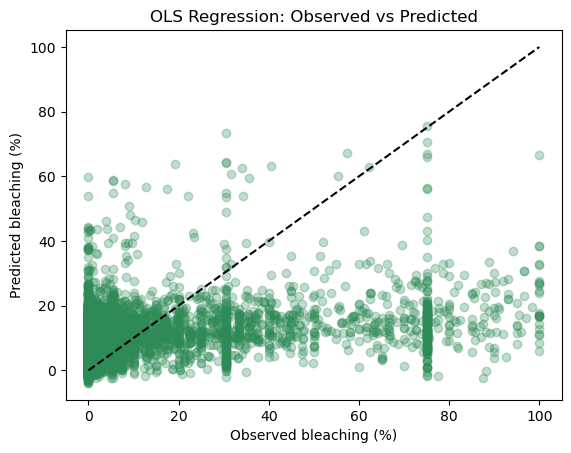

In [116]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_ols, alpha=0.3, color = 'seagreen')
plt.plot([0, 100], [0, 100], linestyle="--", color="black")
plt.xlabel("Observed bleaching (%)")
plt.ylabel("Predicted bleaching (%)")
plt.title("OLS Regression: Observed vs Predicted")
plt.show()

##### Interpretation
* Most observations have low observed bleaching (0-40%)
* Model predicts low bleaching for most sites
* Ecological reality = many surveys show little or no bleaching
* Because low bleaching cases dominate → regression is pulled toward optimising performance there
* Underprediction of extremes
* Substantial unexplained variance

### Random Forest Regression
Do nonlinear, interaction‑aware models improve prediction of coral bleaching severity?

Random Forest is well‑suited to coral bleaching because it:
* Captures non‑linear relationships
* Handles interactions automatically
* Is robust to skewed variables and outliers
* Does not assume linearity or normality

In [117]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200, 
    random_state=42, 
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [118]:
y_pred_rf = rf.predict(X_test)

In [119]:
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Performance")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE:  {mae_rf:.2f}")
print(f"R²:   {r2_rf:.3f}")

Random Forest Regression Performance
RMSE: 11.56
MAE:  5.31
R²:   0.663


#### Interpretation
* The Random Forest regressor achieved a substantially improved predictive performance relative to both the linear regression and dummy baseline models. On the test dataset, the model attained an RMSE of 11.56 percentage points, representing a marked reduction in prediction error compared with OLS regression (RMSE ≈ 18.66) and the dummy regressor (RMSE ≈ 19.91).
* The mean absolute error (MAE) decreased to 5.31 percentage points, less than half the error observed for the OLS regression model (≈ 11.7) and the dummy regressor (≈ 13.15). This indicates that, on average, the Random Forest produces considerably more accurate bleaching predictions.
* The Random Forest also achieved a test‑set R² of 0.663, meaning that approximately 66% of the variance in bleaching severity is explained by the model. This represents a major improvement over OLS regression, which explained only around 12% of the variance, and the dummy regressor, which explained virtually none. The strong agreement between training and test‑set performance suggests that the Random Forest generalises well and is not overfitting.
* This large performance gain indicates that coral bleaching is governed by strongly non‑linear relationships and interaction effects among environmental variables, which are not adequately captured by linear models. In particular, tree‑based methods are better able to model thresholds, compounding effects of thermal stress, and complex interactions between depth, exposure, and heat stress metrics.
* Overall, these results demonstrate that flexible machine‑learning approaches are substantially better suited to modelling coral bleaching severity than linear regression. The strong predictive performance of the Random Forest provides clear justification for the use of more advanced ensemble methods, such as XGBoost, as the primary predictive model in this study.

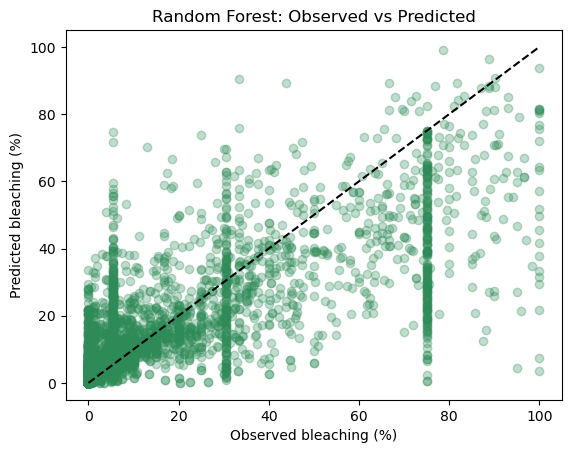

In [120]:
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='seagreen')
plt.plot([0, 100], [0, 100], linestyle="--", color='black')

plt.xlabel("Observed bleaching (%)")
plt.ylabel("Predicted bleaching (%)")
plt.title("Random Forest: Observed vs Predicted")
plt.show()

In [121]:
# Which predictors did the model rely on most to explain variance in bleaching severity?

importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances

Latitude_Degrees     0.158622
Longitude_Degrees    0.155328
SSTA_DHW             0.146771
Cyclone_Frequency    0.101806
Depth_m              0.079166
SSTA_Frequency       0.077352
Distance_to_Shore    0.071611
SSTA                 0.066692
Turbidity            0.048684
SSTA_Maximum         0.048396
Windspeed            0.038031
Exposure             0.007541
const                0.000000
SSTA_Mean            0.000000
dtype: float64

### Tuning Random Forest Regression parameters

In [122]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

In [123]:
param_dist = {
    "n_estimators": [200, 400],
    "max_depth": [None, 15, 25],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.5]
}

In [124]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,         
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

In [125]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                                   random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 15, 25],
                                        'max_features': ['sqrt', 0.5],
                                        'min_samples_leaf': [1, 5, 10],
                                        'n_estimators': [200, 400]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [126]:
# Cross-validated validation RMSE (mean over folds)
val_rmse = -random_search.best_score_

print("Validation performance (5-fold CV on training set)")
print(f"RMSE: {val_rmse:.2f}")

Validation performance (5-fold CV on training set)
RMSE: 12.22


In [127]:
print("Best hyperparameters found:")
print(random_search.best_params_)

Best hyperparameters found:
{'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 25}


In [128]:
best_rf = random_search.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

rmse_rf_tuned = root_mean_squared_error(y_test, y_pred_rf_tuned)
mae_rf_tuned  = mean_absolute_error(y_test, y_pred_rf_tuned)
r2_rf_tuned   = r2_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest Performance")
print(f"RMSE: {rmse_rf_tuned:.2f}")
print(f"MAE:  {mae_rf_tuned:.2f}")
print(f"R²:   {r2_rf_tuned:.3f}")

Tuned Random Forest Performance
RMSE: 11.51
MAE:  5.45
R²:   0.666


In [129]:
# Compare validation and test set metrics
print("Tuned Random Forest Regression Performance:")

print("Validation (CV):")
print(f"RMSE: {val_rmse:.2f}")

print("\nTest set:")
print(f"RMSE: {rmse_rf_tuned:.2f}")
print(f"MAE:  {mae_rf_tuned:.2f}")
print(f"R²:   {r2_rf_tuned:.3f}")

Tuned Random Forest Regression Performance:
Validation (CV):
RMSE: 12.22

Test set:
RMSE: 11.51
MAE:  5.45
R²:   0.666


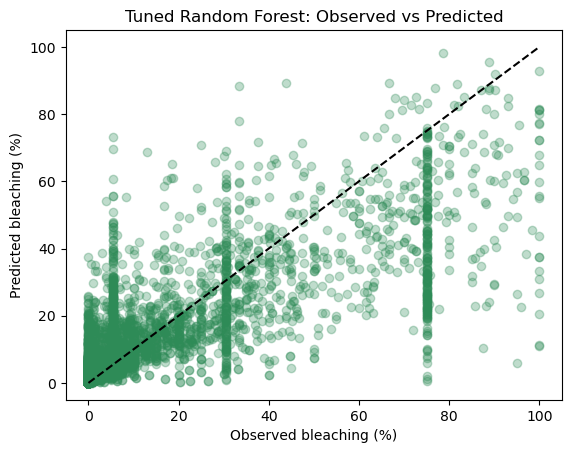

In [130]:
plt.scatter(y_test, y_pred_rf_tuned, alpha=0.3, color='seagreen')
plt.plot([0, 100], [0, 100], linestyle="--", color='black')
plt.xlabel("Observed bleaching (%)")
plt.ylabel("Predicted bleaching (%)")
plt.title("Tuned Random Forest: Observed vs Predicted")
plt.show()

#### Random Forest vs Tuned Random Forest
The untuned Random Forest already performs very strongly, explaining around 66% of the variance in bleaching (R² = 0.663) with relatively low prediction error.
Hyperparameter tuning leads to only a very small improvement in performance:
* RMSE decreases slightly (11.56 → 11.51)
* R² increases marginally (0.663 → 0.666)

MAE increases slightly, indicating no meaningful change in average prediction accuracy.

##### What this means
* The Random Forest model captures most of the available predictive signal even without tuning
* Tuning provides only incremental gains, suggesting the model is already near its optimal performance
* This indicates stable generalisation and low risk of overfitting

### XGBoost Regression
Based on everything I’ve seen so far:
* Linear regression → underfits
* Random Forest → strong nonlinear signal
* Residual structure remains (especially extremes)

XGBoost is ideal because it:
* Models nonlinear responses
* Captures thresholds (e.g. DHW tipping points)
* Learns interactions automatically
* Handles spatial + environmental structure well
* Works extremely well with tabular data

In [131]:
#!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [ ]:
xgb.fit(X_train, y_train)

In [ ]:
y_pred_xgb = xgb.predict(X_test)

In [ ]:
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regression Performance")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE:  {mae_xgb:.2f}")
print(f"R²:   {r2_xgb:.3f}")

* The XGBoost model explains approximately 55% of the variance in coral bleaching severity (R² = 0.55), indicating a substantial improvement in explanatory power compared with linear regression.
* The RMSE of 13.47 percentage points suggests that, on average, model predictions deviate from observed bleaching levels by around 13 percentage points, reflecting improved accuracy in capturing bleaching severity.
* The MAE of 7.53 percentage points indicates that typical prediction errors are relatively moderate, suggesting the model performs well for the majority of observations while larger errors arise from extreme bleaching events.
* The strong performance of XGBoost relative to linear models highlights the importance of non‑linear relationships and interactions in explaining coral bleaching patterns.
* Overall, these results suggest that coral bleaching is driven by complex, non‑linear environmental processes, which are more effectively captured by gradient‑boosted tree models than by traditional regression approaches.

In [ ]:
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='seagreen')
plt.plot([0, 100], [0, 100], linestyle="--", color='black')
plt.xlabel("Observed Bleaching (%)")
plt.ylabel("Predicted Bleaching (%)")
plt.title("XGBoost: Observed vs Predicted")

plt.show()

In [ ]:
importances_xgb = pd.DataFrame(
    xgb.get_booster().get_score(importance_type="gain").items(),
    columns=["Feature", "Importance"]
).sort_values(by="Importance", ascending=False).round(2)

importances_xgb

### Tuning XGBoost parameters

In [ ]:
param_dist = {
    "n_estimators": [300, 500, 700],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10]
}

In [139]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=0.8, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          multi_strategy=None, n_estimators=500,
                                          n_jobs=-1, num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5],
                                        'min_child_weight': [1, 5, 10],
                                        'n_estimators': [300, 500, 700],
                                        'reg_alpha': [0, 0.1, 1],
                                        'reg_lambda': [1, 5, 10],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [140]:
val_rmse_xgb = -random_search.best_score_

print("Validation performance (5-fold CV on training set)")
print(f"RMSE: {val_rmse_xgb:.2f}")

Validation performance (5-fold CV on training set)
RMSE: 13.11


In [141]:
best_xgb = random_search.best_estimator_

print("Best hyperparameters found:")
random_search.best_params_

Best hyperparameters found:


{'subsample': 0.6,
 'reg_lambda': 10,
 'reg_alpha': 1,
 'n_estimators': 700,
 'min_child_weight': 1,
 'max_depth': 5,
 'learning_rate': 0.1,
 'colsample_bytree': 1.0}

In [142]:
y_pred_xgb_tuned = best_xgb.predict(X_test)

rmse_xgb_tuned = root_mean_squared_error(y_test, y_pred_xgb_tuned)
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print("Tuned XGBoost Regression Performance")
print(f"RMSE: {rmse_xgb_tuned:.2f}")
print(f"MAE:  {mae_xgb_tuned:.2f}")
print(f"R²:   {r2_xgb_tuned:.3f}")

Tuned XGBoost Regression Performance
RMSE: 12.61
MAE:  6.95
R²:   0.599


In [143]:
print("Tuned XGBoost Regression Performance:")

print("Validation (CV):")
print(f"RMSE: {val_rmse_xgb:.2f}")

print("\nTest set:")
print(f"RMSE: {rmse_xgb_tuned:.2f}")
print(f"MAE:  {mae_xgb_tuned:.2f}")
print(f"R²:   {r2_xgb_tuned:.3f}")

Tuned XGBoost Regression Performance:
Validation (CV):
RMSE: 13.11

Test set:
RMSE: 12.61
MAE:  6.95
R²:   0.599


* Prediction accuracy improved across all metrics after tuning.
* The reduction in RMSE indicates that large prediction errors were reduced, suggesting better performance on more extreme bleaching values.
* The decrease in MAE shows improved average predictive accuracy across all observations.
* The increase in R² indicates that the tuned model explains a greater proportion of variance in observed bleaching.

These improvements demonstrate that hyperparameter tuning meaningfully enhanced model generalisation, rather than simply improving fit to the training data.

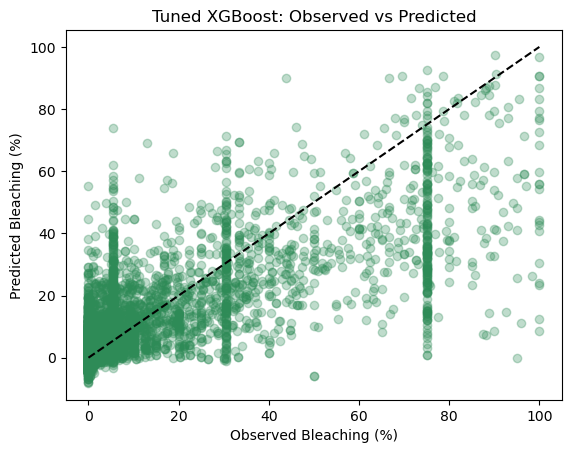

In [144]:
plt.scatter(y_test, y_pred_xgb_tuned, alpha=0.3, color='seagreen')
plt.plot([0, 100], [0, 100], linestyle="--", color='black')
plt.xlabel("Observed Bleaching (%)")
plt.ylabel("Predicted Bleaching (%)")
plt.title("Tuned XGBoost: Observed vs Predicted")

plt.show()

In [145]:
results = pd.DataFrame({
    "Model": [
        "Dummy Regressor",
        "Linear Regression",
        "Tuned Random Forest Regressor",
        "Tuned XGBoost Regressor"
    ],
    "RMSE": [
        rmse_d,
        rmse_ols,
        rmse_rf_tuned,
        rmse_xgb_tuned
    ],
    "MAE": [
        mae_d,
        mae_ols,
        mae_rf_tuned,
        mae_xgb_tuned
    ],
    "R2": [
        r2_d,
        r2_ols,
        r2_rf_tuned,
        r2_xgb_tuned
    ]
})

results

,Model,RMSE,MAE,R2
0,Dummy Regressor,19.910613,13.152915,-0.000064
1,Linear Regression,18.663348,11.708859,0.121306
2,Tuned Random Forest Regressor,11.505358,5.454499,0.666067
3,Tuned XGBoost Regressor,12.608991,6.949820,0.598931


In [146]:
results_rounded = results.copy()
results_rounded["RMSE"] = results_rounded["RMSE"].round(2)
results_rounded["MAE"] = results_rounded["MAE"].round(2)
results_rounded["R2"] = results_rounded["R2"].round(3)

results_rounded

,Model,RMSE,MAE,R2
0,Dummy Regressor,19.91,13.15,-0.000
1,Linear Regression,18.66,11.71,0.121
2,Tuned Random Forest Regressor,11.51,5.45,0.666
3,Tuned XGBoost Regressor,12.61,6.95,0.599


#### Overall model comparison
* The dummy regressor achieved an R² of approximately 0.000, confirming that it explains virtually none of the variance in bleaching severity and serves solely as a no‑skill baseline.
* Linear regression improved performance modestly, explaining approximately 12% of the variance in percent bleaching, indicating the presence of some linear signal in the predictors.
* Tuning of Random Forest regression achieved the strongest performance, with an R² of 0.666, explaining 67% of the variability in bleaching severity.
* XGBoost regression also performed strongly (R² = 0.599), substantially outperforming linear regression but not exceeding Random Forest in this configuration.

#### Error‑based metrics (RMSE & MAE)
* RMSE and MAE decrease substantially from dummy → linear → tree‑based models, indicating progressively improved predictive accuracy.
* The tuned Random Forest regressor achieved the lowest RMSE (11.51) and lowest MAE (5.45), showing the strongest ability to predict both typical and extreme bleaching values.
* The tuned XGBoost reduced error relative to linear regression but exhibited higher error than Random Forest, suggesting either: mild over‑regularisation or that the Random Forest structure better matches this dataset’s signal‑to‑noise characteristics.

#### Scientific interpretation
* The large jump in performance between linear regression and tree‑based models demonstrates that bleaching severity is governed by nonlinear responses and interacting environmental drivers.
* Linear regression’s limited R² and characteristic underprediction of higher bleaching values indicate that additive linear assumptions are insufficient.
* The strong performance of Random Forest and XGBoost supports modelling coral bleaching as a threshold‑driven, spatially structured ecological process rather than a purely linear response.

## SHapley Additive exPlanations

In [147]:
import shap

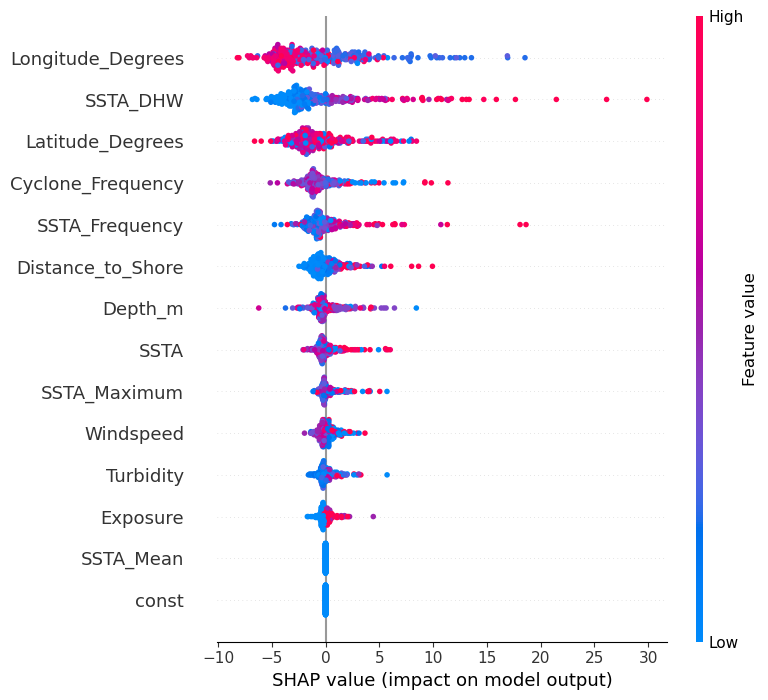

In [148]:
model = best_rf
X_shap = X_test.sample(n=300, random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap,check_additivity=False)
shap.summary_plot(shap_values, X_shap)

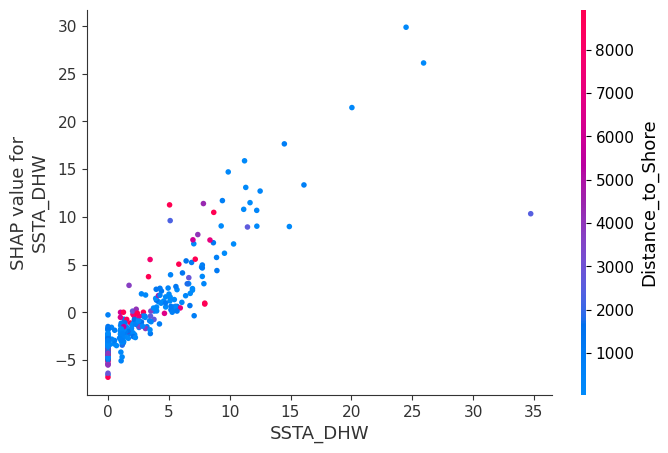

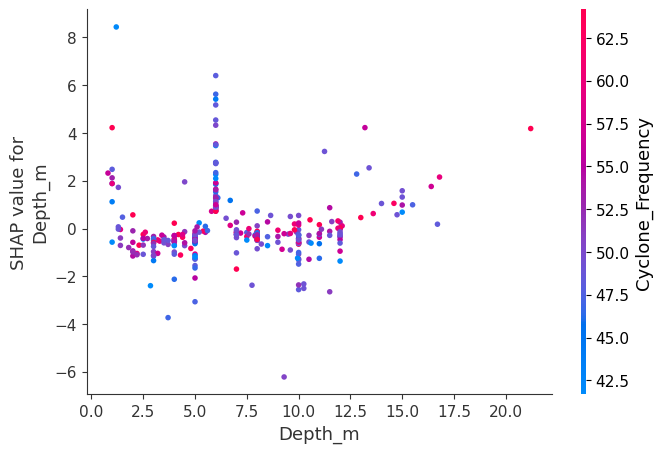

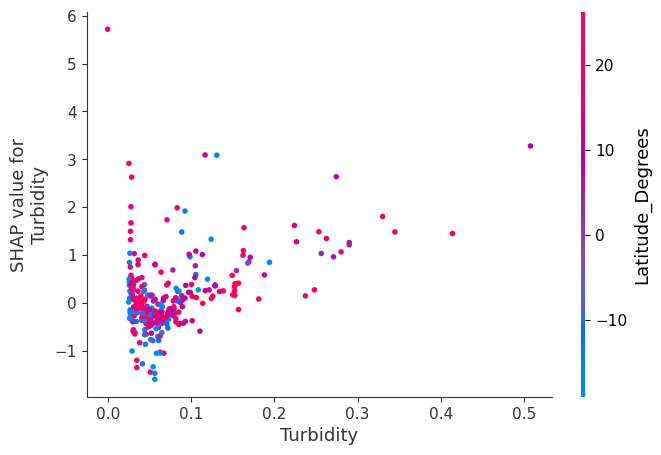

In [149]:
shap.dependence_plot("SSTA_DHW", shap_values, X_shap)
shap.dependence_plot("Depth_m", shap_values, X_shap)
shap.dependence_plot("Turbidity", shap_values, X_shap)

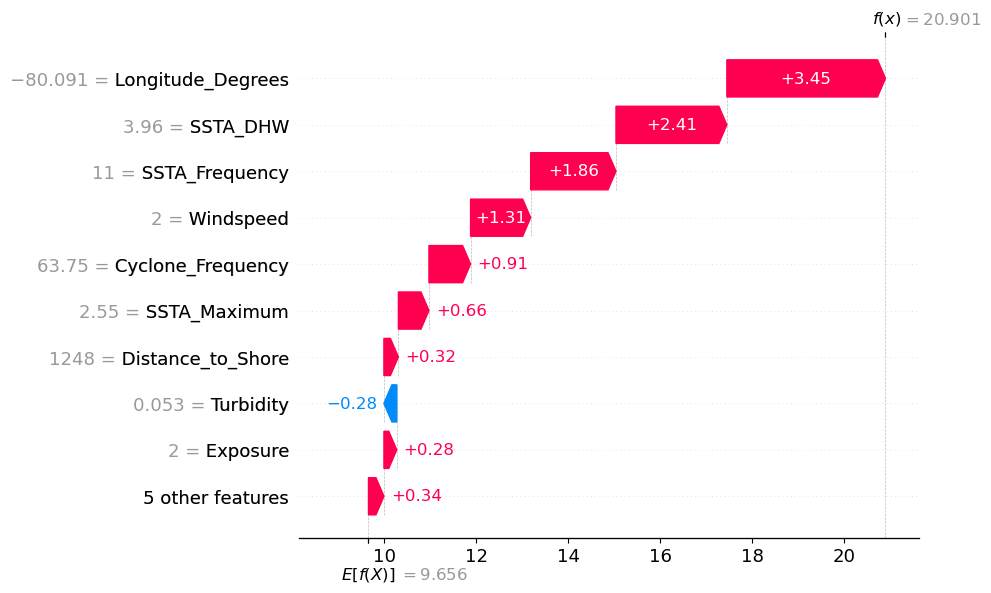

In [150]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_shap.iloc[0],
        feature_names=X_shap.columns
    )
)